In [1]:
import numpy as np
import pandas as pd
import scanpy as sc 

adata = sc.read_h5ad("dataset_co_mo.h5ad")

In [2]:
# Data prep
sc.pp.normalize_total(adata, target_sum=1e4) # You can adjust target_sum # Seems not to help
sc.pp.log1p(adata)

In [3]:
# Extract source and receiver genes efficiently
#gl_source = ['TGFBR2', 'SMAD3', 'HIF1A', 'PDGFB'] # All values from the first column
#gl_recv =['PDGFRB', 'FN1', 'TGFB1']  # All values from the second column

#gl_source = ['TGFBR2', 'HIF1A', 'PDGFB'] # All values from the first column
#gl_recv =['PDGFRB', 'FN1', 'TGFB1']  # All values from the second column

gl_source = ['TGFBR2', 'PDGFB'] # All values from the first column
gl_recv =['PDGFRB', 'TGFB1']  # All values from the second column

np.random.seed(42) 
pi_mul = np.pi

In [4]:
ict1 = adata.obs["BatchID"] == "Cancer Cells (Co)"
ict2 = adata.obs["BatchID"] == "Fibroblasts (Co)" 

adata_ct1_co = adata[ict1, gl_source]
adata_ct2_co = adata[ict2, gl_recv]
#adata_ct1_co = sc.external.pp.magic(adata_ct1_co, name_list=gl_source, knn=5, random_state=42)
#adata_ct2_co = sc.external.pp.magic(adata_ct2_co, name_list=gl_recv, knn=5, random_state=42)

print(adata_ct1_co)
print(adata_ct2_co)

Xct1_co = adata_ct1_co.X.toarray()
Xct2_co = adata_ct2_co.X.toarray()
#Xct1_co = adata_ct1_co.X
#Xct2_co = adata_ct2_co.X

# Assuming Xct1_co and Xct2 are your log-transformed expression matrices
Xct1means = np.mean(Xct1_co, axis=0) *0
Xct2means = np.mean(Xct2_co, axis=0) *0
print("CT1 (Co) mean expression:", Xct1means)
print("CT2 (Co) mean expression:", Xct2means)

# Binarize Xct1
Xct1_binary_co = (Xct1_co > Xct1means).astype(int)
# Binarize Xct2
Xct2_binary_co = (Xct2_co > Xct2means).astype(int)

# Calculate the proportion of cells with expression above mean for each gene in ct1
Xct1p_co = np.sum(Xct1_binary_co, axis=0) / len(Xct1_binary_co[:, 0])
# Calculate the proportion of cells with expression above mean for each gene in ct2
Xct2p_co = np.sum(Xct2_binary_co, axis=0) / len(Xct2_binary_co[:, 0])

print("CT1 (Co) Percentages:", Xct1p_co)
print("CT2 (Co) Percentages:", Xct2p_co)

# Scale the data from 0 to 1 to -pi/2 to pi/2 | 2*pi or pi?
#ct1_percentages_co = (Xct1p_co -0.5) * pi_mul + np.pi
#ct2_percentages_co = (Xct2p_co -0.5) * pi_mul + np.pi
ct1_percentages_co = Xct1p_co * pi_mul 
ct2_percentages_co = Xct2p_co * pi_mul 

# Display the resulting scaled data
print("Scaled (Co) ct1_data:\n", ct1_percentages_co)
print("Scaled (Co) ct2_data:\n", ct2_percentages_co)

View of AnnData object with n_obs × n_vars = 1414 × 2
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
    uns: 'log1p'
View of AnnData object with n_obs × n_vars = 1324 × 2
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
    uns: 'log1p'
CT1 (Co) mean expression: [0. 0.]
CT2 (Co) mean expression: [0. 0.]
CT1 (Co) Percentages: [0.3748232  0.29915134]
CT2 (Co) Percentages: [0.41993958 0.51812689]
Scaled (Co) ct1_data:
 [1.1775418  0.93981166]
Scaled (Co) ct2_data:
 [1.31927909 1.62774363]


In [5]:
ict1 = adata.obs["BatchID"] == "Cancer Cells (Mo)"
ict2 = adata.obs["BatchID"] == "Fibroblasts (Mo)" 

adata_ct1_mo = adata[ict1, gl_source]
adata_ct2_mo = adata[ict2, gl_recv]
#adata_ct1_mo = sc.external.pp.magic(adata_ct1_mo, name_list=gl_source, knn=5, random_state=42)
#adata_ct2_mo = sc.external.pp.magic(adata_ct2_mo, name_list=gl_recv, knn=5, random_state=42)

print(adata_ct1_mo)
print(adata_ct2_mo)

# Library size normalization 
Xct1_mo = adata_ct1_mo.X.toarray()
Xct2_mo = adata_ct2_mo.X.toarray()
#Xct1_mo = adata_ct1_mo.X
#Xct2_mo = adata_ct2_mo.X


# Assuming Xct1_co and Xct2 are your log-transformed expression matrices
#Xct1means = np.mean(Xct1_mo, axis=0)
#Xct2means = np.mean(Xct2_mo, axis=0)
#print("CT1 (Co) mean expression:", Xct1means)
#print("CT2 (Co) mean expression:", Xct2means)

# Utilize the mono cultured means here
# Binarize Xct1
Xct1_binary_mo = (Xct1_mo > Xct1means).astype(int)
# Binarize Xct2
Xct2_binary_mo = (Xct2_mo > Xct2means).astype(int)

# Calculate the proportion of cells with expression above mean for each gene in ct1
Xct1p_mo = np.sum(Xct1_binary_mo, axis=0) / len(Xct1_binary_mo[:, 0])

# Calculate the proportion of cells with expression above mean for each gene in ct2
Xct2p_mo = np.sum(Xct2_binary_mo, axis=0) / len(Xct2_binary_mo[:, 0])

print("CT1 (Mo) Percentages:", Xct1p_mo)
print("CT2 (Mo) Percentages:", Xct2p_mo)

# Scale the data from 0 to 1 to -pi/2 to pi/2 | 2*pi or pi?
#ct1_percentages_mo = (Xct1p_mo -0.5) * pi_mul + np.pi/2
#ct2_percentages_mo = (Xct2p_mo -0.5) * pi_mul + np.pi/2
ct1_percentages_mo = Xct1p_mo * pi_mul 
ct2_percentages_mo = Xct2p_mo * pi_mul

# Display the resulting scaled data
print("Scaled (Mo) ct1_data:\n", ct1_percentages_mo)
print("Scaled (Mo) ct2_data:\n", ct2_percentages_mo)

View of AnnData object with n_obs × n_vars = 2364 × 2
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
    uns: 'log1p'
View of AnnData object with n_obs × n_vars = 2788 × 2
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
    uns: 'log1p'
CT1 (Mo) Percentages: [0.36759729 0.09898477]
CT2 (Mo) Percentages: [0.29196557 0.42969871]
Scaled (Mo) ct1_data:
 [1.15484095 0.31096983]
Scaled (Mo) ct2_data:
 [0.91723688 1.34993831]


In [6]:
print(adata_ct1_co.var_names)
print(adata_ct2_co.var_names)

Index(['TGFBR2', 'PDGFB'], dtype='object')
Index(['PDGFRB', 'TGFB1'], dtype='object')


In [7]:
import sys
import os

# Replace with your actual path
cc_grn_functions_path = r"C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions"
sys.path.append(cc_grn_functions_path)

from histogram_functions import create_joint_histogram, plot_joint_histogram, create_percent_joint_histogram, count_boolean_vector_occurrences

In [8]:
import sys
import os

# Replace with your actual path
cc_grn_functions_path = r"C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions"
sys.path.append(cc_grn_functions_path)

from quantum_functions import create_grn_ansatz, create_interaction_observable_from_histogram, evaluate_and_plot_ansatz
from quantum_functions import create_parameter_dictionaries, cost_func_vqe, cost_func_wrapper
from quantum_functions import create_interaction_observable_general, create_parameter_dictionaries_from_circuit, create_joint_circuit_from_ansatzes, vqe_solver
import matplotlib.pyplot as plt

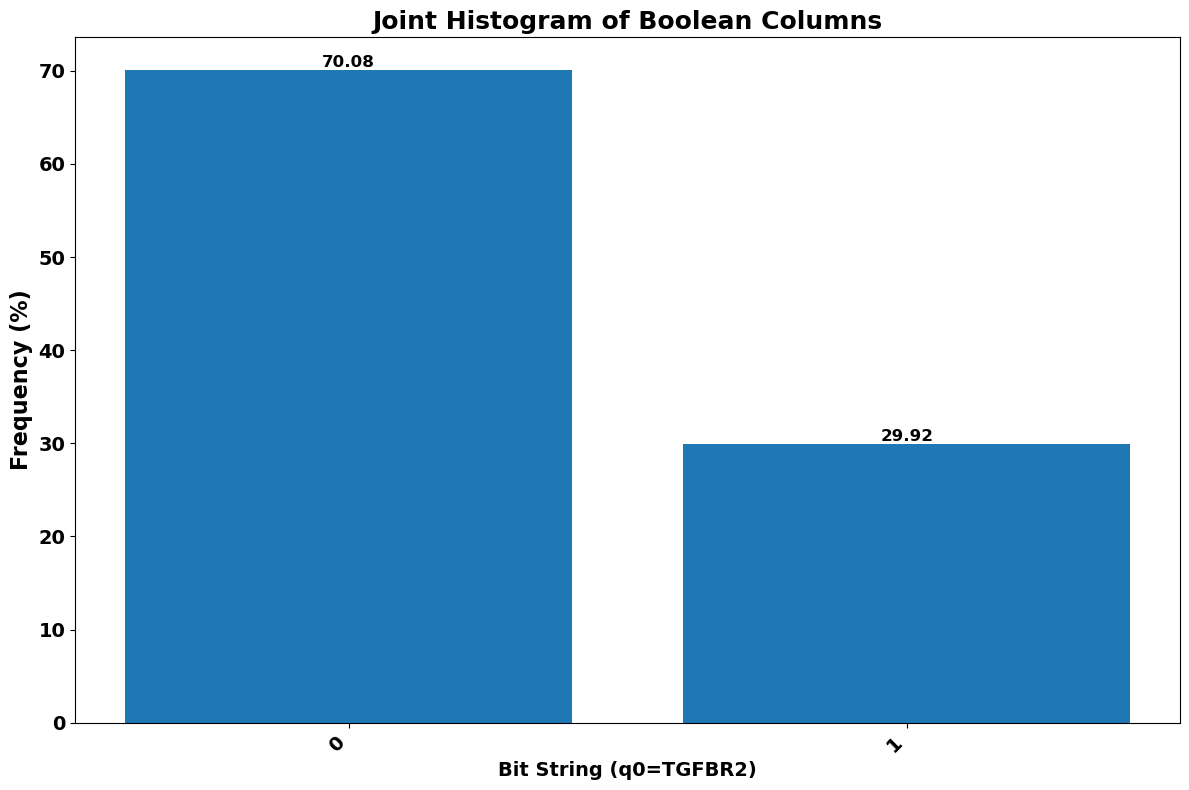

Joint Counts: {'1': 29.915134370579917, '0': 70.0848656294201}


In [ ]:
#Xct1_binary_co
#Xct2_binary_co
#Xct1_binary_mo
#Xct2_binary_mo

#joint_counts = count_boolean_vector_occurrences(Xct1_binary_co[:,0])
joint_counts, sorted_bit_strings = create_percent_joint_histogram(np.asarray( [Xct1_binary_co[:,0]] ).T)

act_ct1 = np.asarray([ct1_percentages_co[0]])
num_qubits = 1 
plot_joint_histogram(joint_counts, num_qubits, reverse_bits=True, features=gl_source)  # Pass num_qubits

print("Joint Counts:", joint_counts)

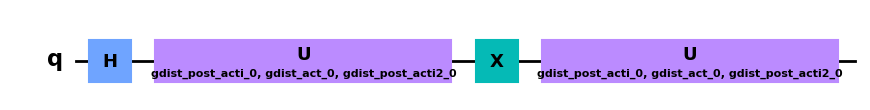

In [34]:
ansatz_grn = create_grn_ansatz(1, "Gdist")
ansatz_grn.draw(output="mpl", style="clifford", fold=40)

Interaction observable CT from histogram: SparsePauliOp(['I', 'Z'],
              coeffs=[-50.        +0.j, -20.08486563+0.j])
Static Parameters: {Parameter(gdist_act_0): 0.9398116636976538}
Variable Parameters: {Parameter(gdist_post_acti2_0): 0.0, Parameter(gdist_post_acti_0): 0.0}
Starting optimization with method: COBYLA
Iteration 0: Current cost: -49.99999999999999
Iteration 20: Current cost: -67.3048292190761
Iteration 40: Current cost: -67.38264546304171

Optimization Result:
 message: Optimization terminated successfully.
 success: True
  status: 1
     fun: -67.38300169360019
       x: [ 2.408e+00 -1.047e+00]
    nfev: 56
   maxcv: 0.0

Final Energy: -67.38300169360019

Optimized Full Parameters:
  gdist_act_0: 0.9398116636976538
  gdist_post_acti2_0: 2.4076661109320003
  gdist_post_acti_0: -1.047105351775405


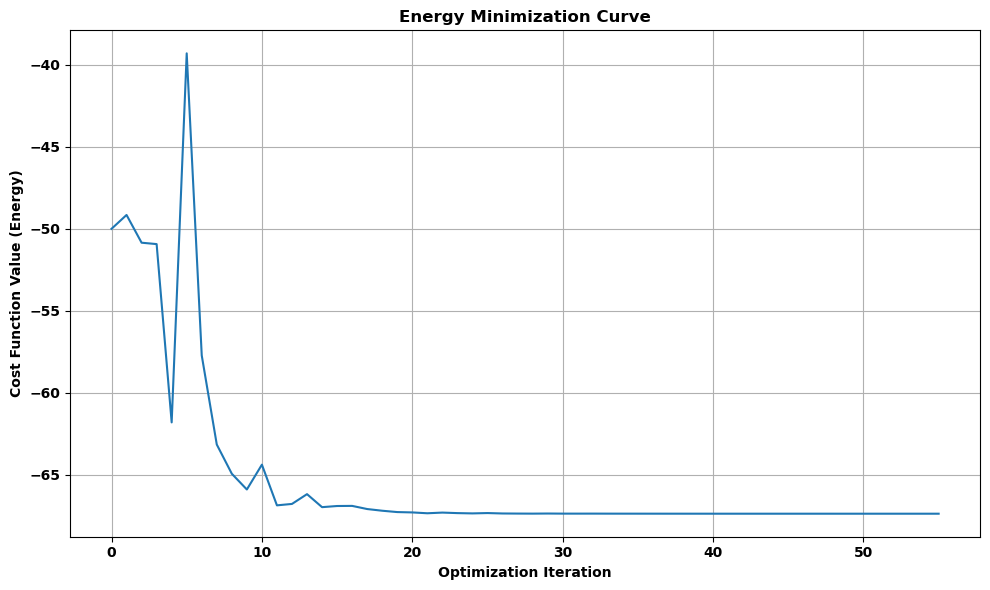

The counts are: {'0': 956, '1': 68}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:376: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


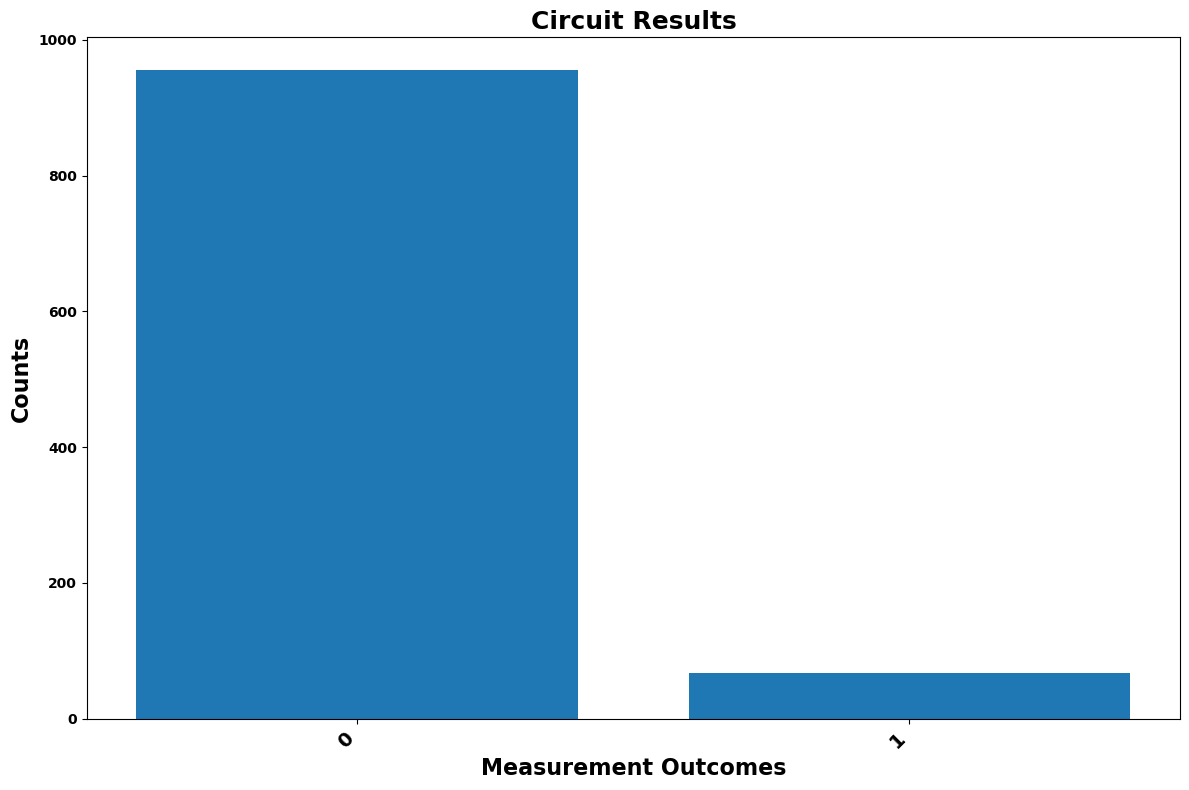

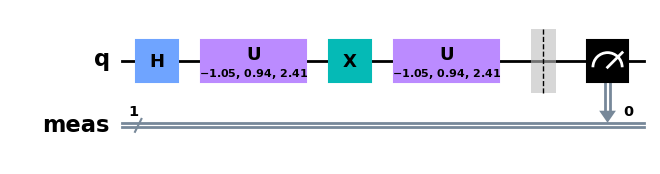

In [35]:
min_ones = 0

result_interaction_bfgs, optimized_full_params, cost_values = vqe_solver(
    joint_counts,
    ansatz_grn, # Renamed from 'cirquit' for common convention
    act_ct1, # Renamed from 'act_percentages' for consistency with create_parameter_dictionaries_cust
    cost_func_wrapper, # This function needs to be defined to accept the correct arguments (see comments below)
    min_ones_obs=min_ones, # Added as an explicit argument for flexibility
    optimizer_method="COBYLA",# COBYLA | L-BFGS-B
)

# Plot the cost function values
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
plt.show()
counts, bound_circuit = evaluate_and_plot_ansatz(ansatz_grn, optimized_full_params, shots=1024, title="Circuit Results")
bound_circuit.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

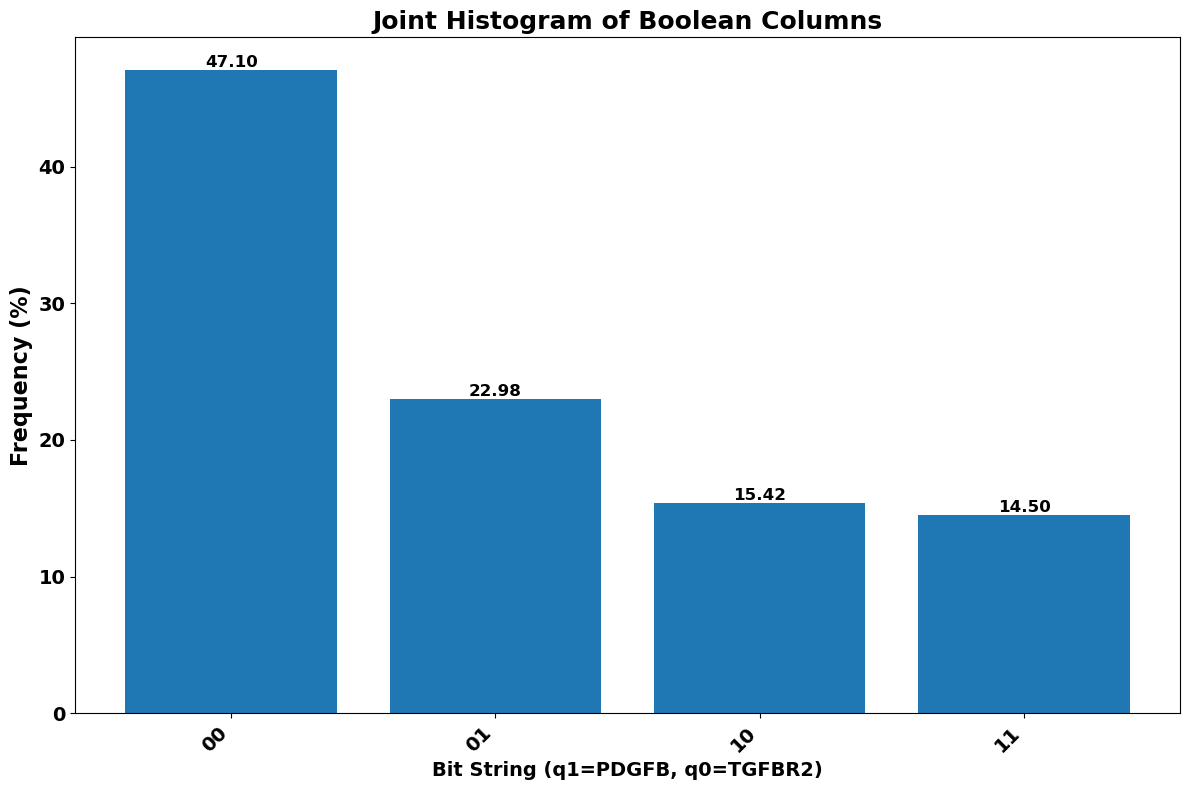

Joint Counts: {'01': 15.417256011315416, '10': 22.984441301272984, '00': 47.1004243281471, '11': 14.497878359264499}
Bit Strings: ['00', '01', '10', '11']


In [12]:
#joint_counts_ct1_co, bit_strings_ct1_co = create_joint_histogram(Xct1_binary_co)
joint_counts_ct1_co, bit_strings_ct1_co = create_percent_joint_histogram(Xct1_binary_co)

num_qubits = Xct1_binary_co.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct1_co, num_qubits, reverse_bits=True, features=gl_source)  # Pass num_qubits

print("Joint Counts:", joint_counts_ct1_co)
print("Bit Strings:", bit_strings_ct1_co)

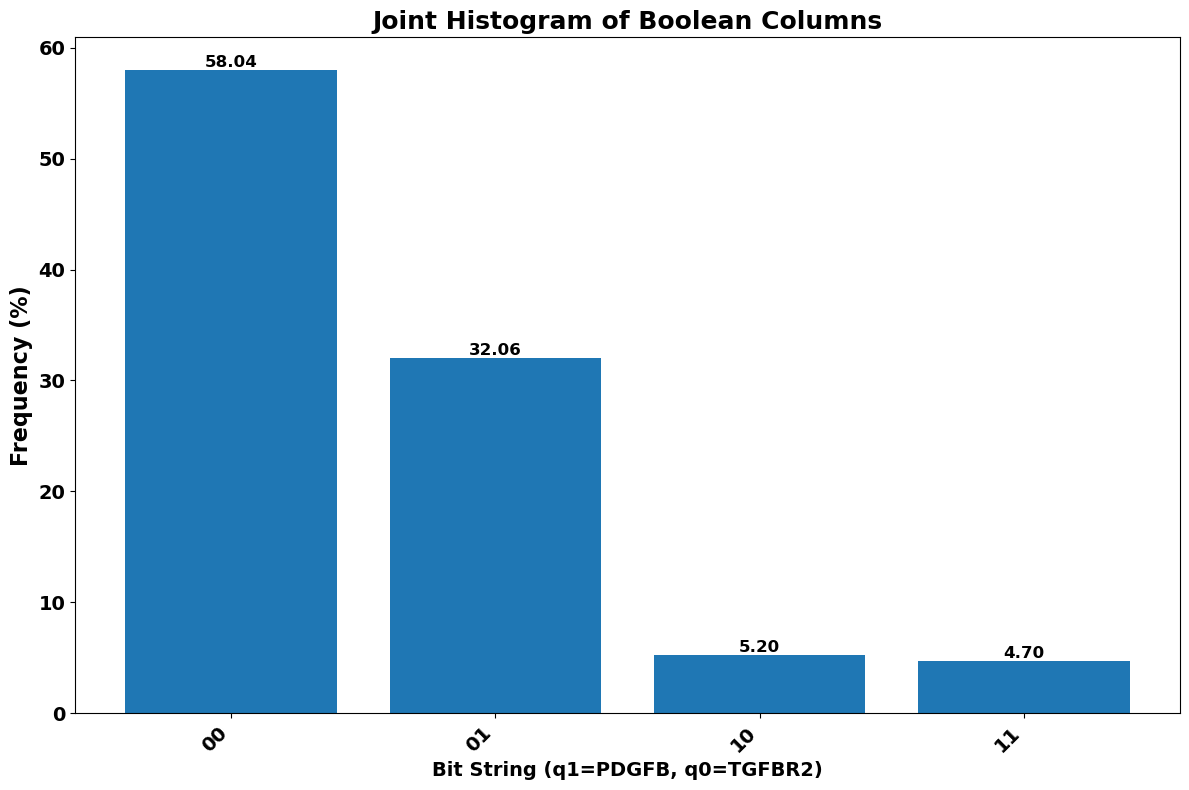

Joint Counts: {'00': 58.03722504230119, '11': 4.695431472081219, '10': 32.06429780033841, '01': 5.203045685279188}
Bit Strings: ['00', '01', '10', '11']


In [13]:
#joint_counts_ct1_mo, bit_strings_ct1_mo = create_joint_histogram(Xct1_binary_mo)
joint_counts_ct1_mo, bit_strings_ct1_mo = create_percent_joint_histogram(Xct1_binary_mo)

num_qubits = Xct1_binary_mo.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct1_mo, num_qubits, reverse_bits=True, features=gl_source )  # Pass num_qubits

print("Joint Counts:", joint_counts_ct1_mo)
print("Bit Strings:", bit_strings_ct1_mo)

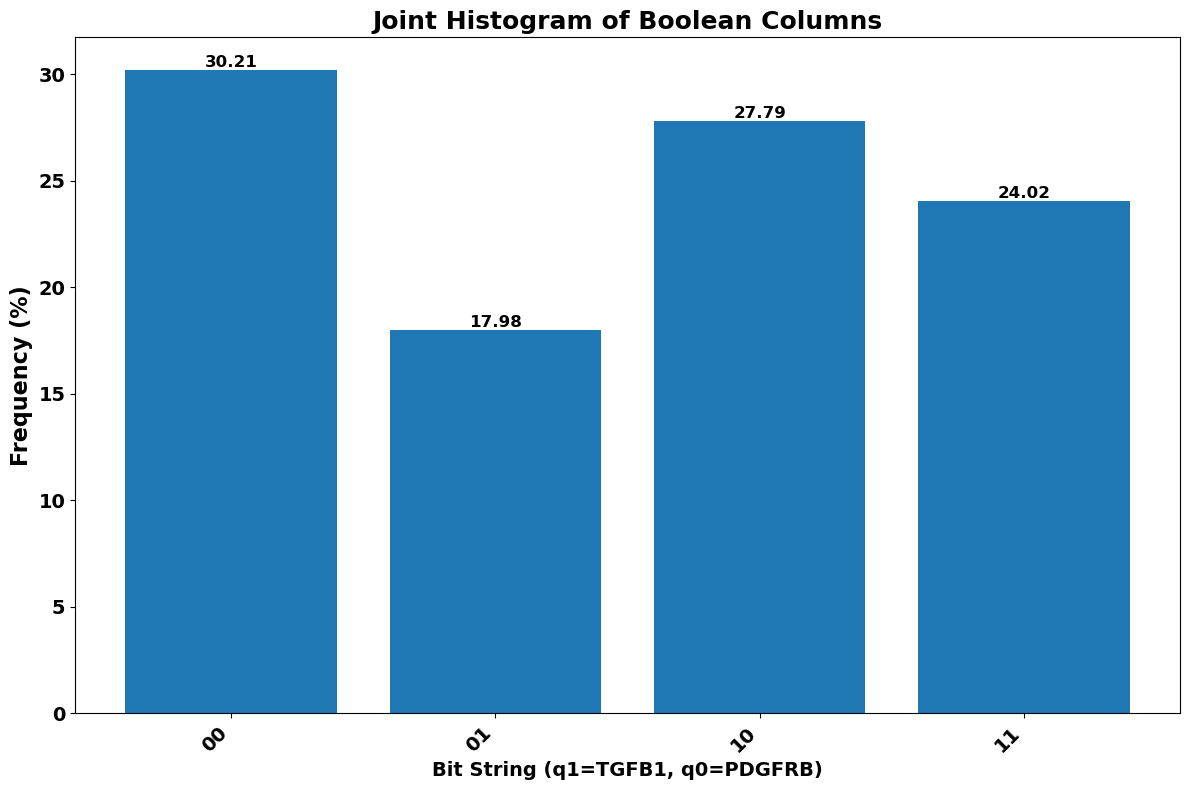

Joint Counts: {'00': 30.211480362537763, '11': 24.018126888217523, '01': 27.794561933534744, '10': 17.97583081570997}
Bit Strings: ['00', '01', '10', '11']


In [14]:
#joint_counts_ct2_co, bit_strings_ct2_co = create_joint_histogram(Xct2_binary_co)
joint_counts_ct2_co, bit_strings_ct2_co = create_percent_joint_histogram(Xct2_binary_co)

num_qubits2 = Xct2_binary_co.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct2_co, num_qubits2, reverse_bits=True, features=gl_recv)  # Pass num_qubits

print("Joint Counts:", joint_counts_ct2_co)
print("Bit Strings:", bit_strings_ct2_co)

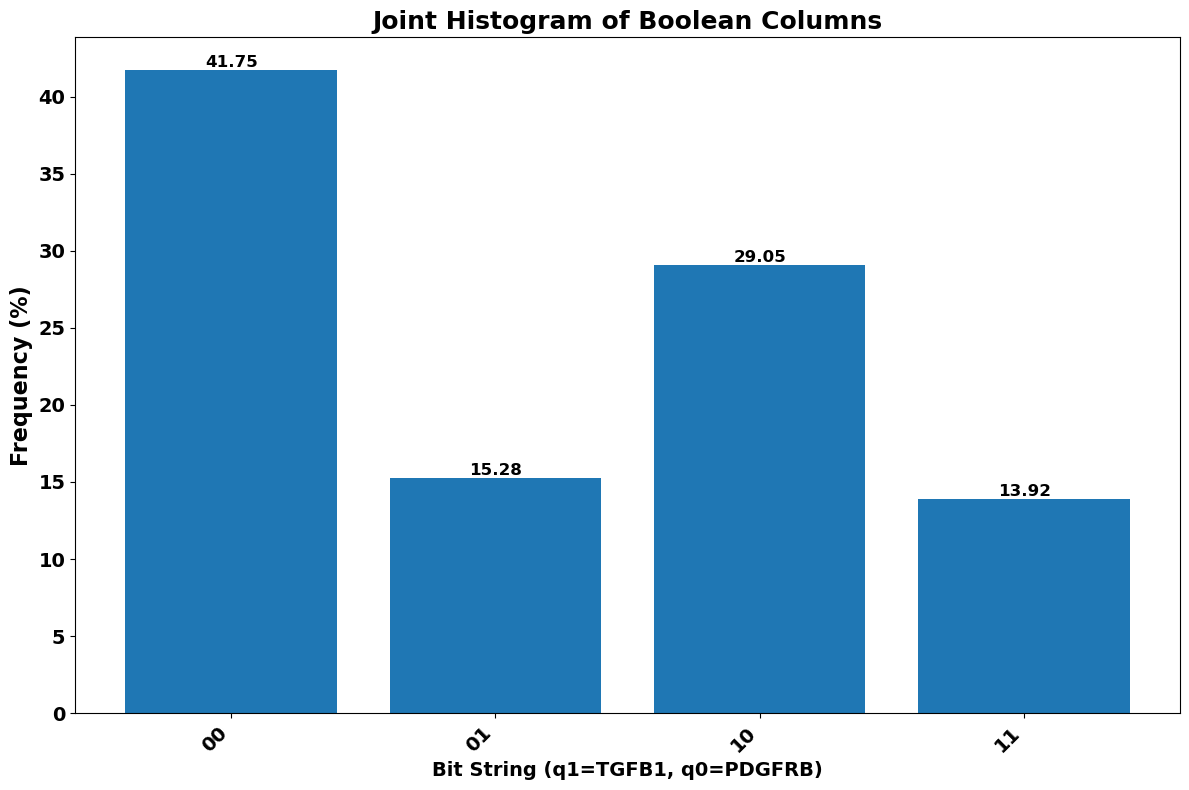

Joint Counts: {'11': 13.916786226685796, '00': 41.75035868005739, '01': 29.053084648493545, '10': 15.27977044476327}
Bit Strings: ['00', '01', '10', '11']


In [15]:
#joint_counts_ct2_mo, bit_strings_ct2_mo = create_joint_histogram(Xct2_binary_mo)
joint_counts_ct2_mo, bit_strings_ct2_mo = create_percent_joint_histogram(Xct2_binary_mo)

num_qubits2 = Xct2_binary_mo.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct2_mo, num_qubits2, reverse_bits=True, features=gl_recv)  # Pass num_qubits

print("Joint Counts:", joint_counts_ct2_mo)
print("Bit Strings:", bit_strings_ct2_mo)

In [16]:
import sys
import os

# Replace with your actual path
cc_grn_functions_path = r"C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions"
sys.path.append(cc_grn_functions_path)

from quantum_functions import create_grn_ansatz, create_interaction_observable_from_histogram, evaluate_and_plot_ansatz
from quantum_functions import create_parameter_dictionaries, cost_func_vqe, cost_func_wrapper
from quantum_functions import create_interaction_observable_general, create_parameter_dictionaries_from_circuit, create_joint_circuit_from_ansatzes, vqe_solver
import matplotlib.pyplot as plt

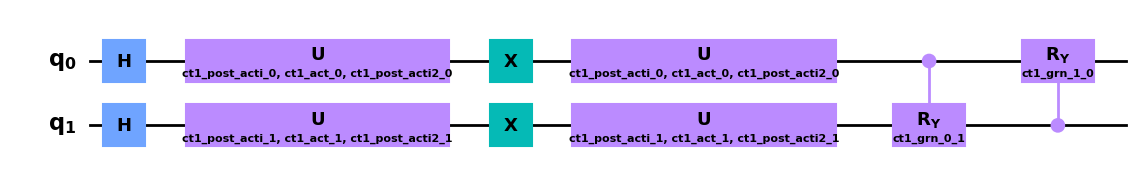

In [17]:
ng_ct1 = len(gl_source)  # Assuming gl_source is defined elsewhere
# Create mono coltured grn
ansatz_grn_ct1_mo = create_grn_ansatz(ng_ct1, "CT1")
# Create co cultured grn
ansatz_grn_ct1_co = create_grn_ansatz(ng_ct1, "CT1")
ansatz_grn_ct1_mo.draw(output="mpl", style="clifford", fold=40)

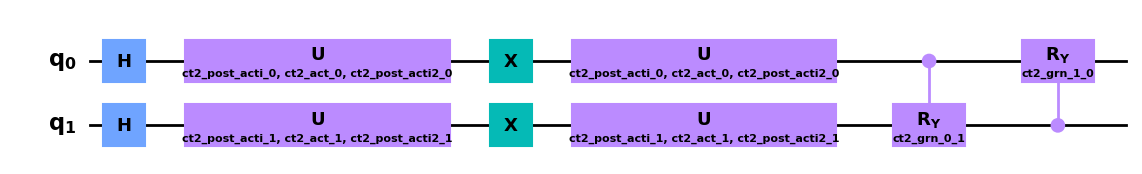

In [18]:
ng_ct2 = len(gl_recv)  #Example for a second cell type
# Create mo cultured grn
ansatz_grn_ct2_mo = create_grn_ansatz(ng_ct2, "CT2")
# Create co cultured grn
ansatz_grn_ct2_co = create_grn_ansatz(ng_ct2, "CT2")
ansatz_grn_ct2_mo.draw(output="mpl", style="clifford", fold=40)

Interaction observable CT from histogram: SparsePauliOp(['II', 'IZ', 'ZI', 'ZZ'],
              coeffs=[-25.        +0.j, -10.04243281+0.j,  -6.25884017+0.j,  -5.79915134+0.j])
Static Parameters: {Parameter(ct1_act_0): 1.1775418008504883, Parameter(ct1_act_1): 0.9398116636976538}
Variable Parameters: {Parameter(ct1_grn_0_1): 0.0, Parameter(ct1_grn_1_0): 0.0, Parameter(ct1_post_acti2_0): 0.0, Parameter(ct1_post_acti2_1): 0.0, Parameter(ct1_post_acti_0): 0.0, Parameter(ct1_post_acti_1): 0.0}
Starting optimization with method: COBYLA
Iteration 0: Current cost: -24.80659259542957
Iteration 20: Current cost: -34.23472883500386
Iteration 40: Current cost: -35.672136086083974
Iteration 60: Current cost: -35.73353853922035
Iteration 80: Current cost: -35.76513892552288
Iteration 100: Current cost: -35.78589927235019
Iteration 200: Current cost: -35.842917523288946
Iteration 300: Current cost: -35.85746601937011
Iteration 400: Current cost: -35.860706524779545
Iteration 500: Current cost: -35.8

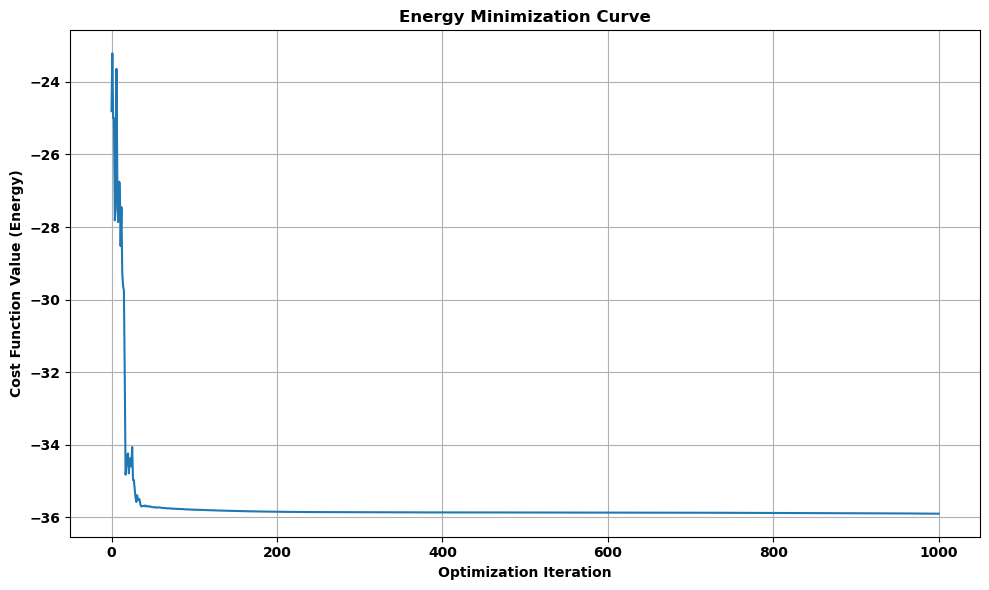

The counts are: {'00': 647, '10': 77, '01': 298, '11': 2}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:376: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


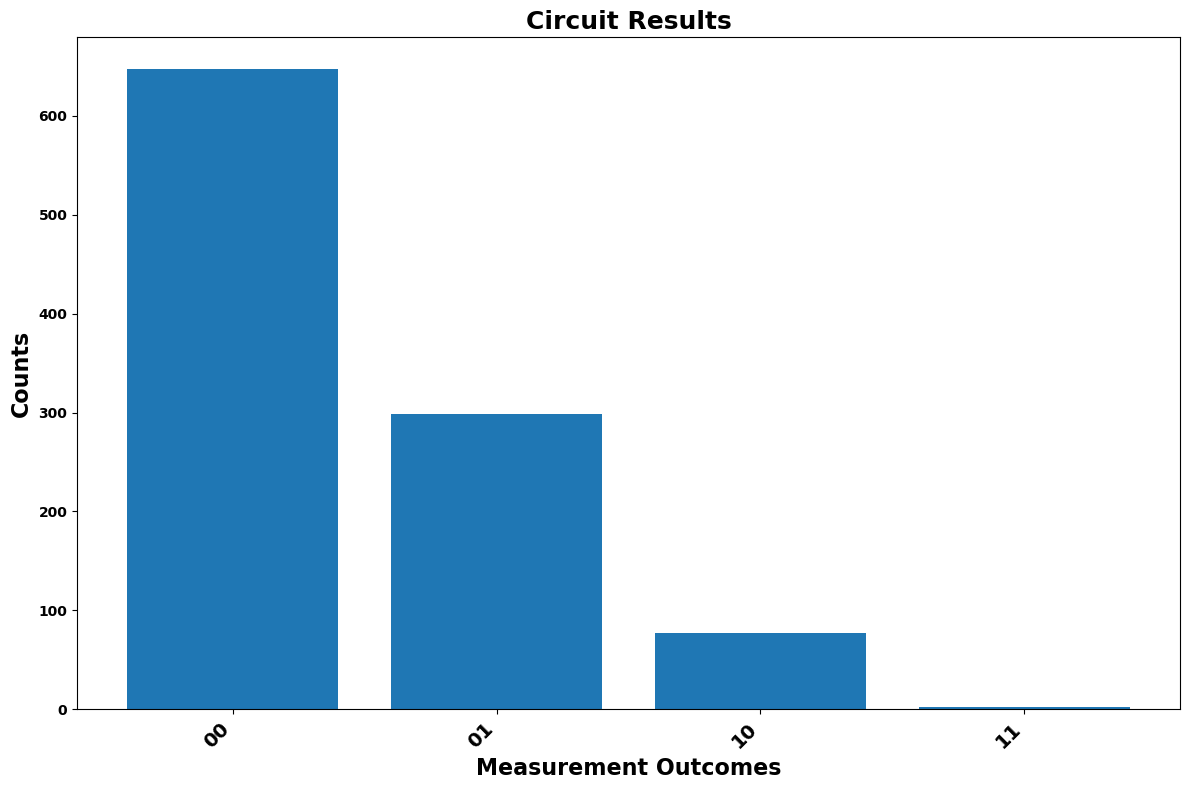

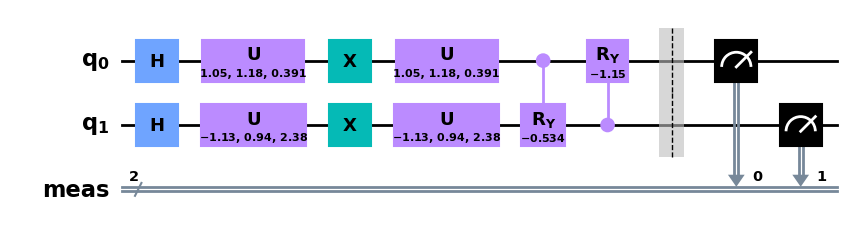

In [19]:
min_ones = 0

result_interaction_bfgs, optimized_full_params_ct1_co, cost_values = vqe_solver(
    joint_counts_ct1_co,
    ansatz_grn_ct1_co, # Renamed from 'cirquit' for common convention
    ct1_percentages_co, # Renamed from 'act_percentages' for consistency with create_parameter_dictionaries_cust
    cost_func_wrapper, # This function needs to be defined to accept the correct arguments (see comments below)
    min_ones_obs=min_ones, # Added as an explicit argument for flexibility
    optimizer_method="COBYLA",# COBYLA | L-BFGS-B
)

# Plot the cost function values
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
plt.show()
counts, bound_circuit = evaluate_and_plot_ansatz(ansatz_grn_ct1_co, optimized_full_params_ct1_co, shots=1024, title="Circuit Results")
bound_circuit.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

Interaction observable CT from histogram: SparsePauliOp(['II', 'IZ', 'ZI', 'ZZ'],
              coeffs=[-25.        +0.j, -20.05076142+0.j,  -6.62013536+0.j,  -6.36632826+0.j])
Static Parameters: {Parameter(ct1_act_0): 1.1548409543018316, Parameter(ct1_act_1): 0.31096983119289834}
Variable Parameters: {Parameter(ct1_grn_0_1): 0.0, Parameter(ct1_grn_1_0): 0.0, Parameter(ct1_post_acti2_0): 0.0, Parameter(ct1_post_acti2_1): 0.0, Parameter(ct1_post_acti_0): 0.0, Parameter(ct1_post_acti_1): 0.0}
Starting optimization with method: COBYLA
Iteration 0: Current cost: -24.89321434202944
Iteration 20: Current cost: -39.32031943599393
Iteration 40: Current cost: -45.28630500528886
Iteration 60: Current cost: -48.14160360072855
Iteration 80: Current cost: -48.850393974955
Iteration 100: Current cost: -49.21251530863214
Iteration 200: Current cost: -49.45021379288731
Iteration 300: Current cost: -49.452454053450175

Optimization Result:
 message: Optimization terminated successfully.
 success: True


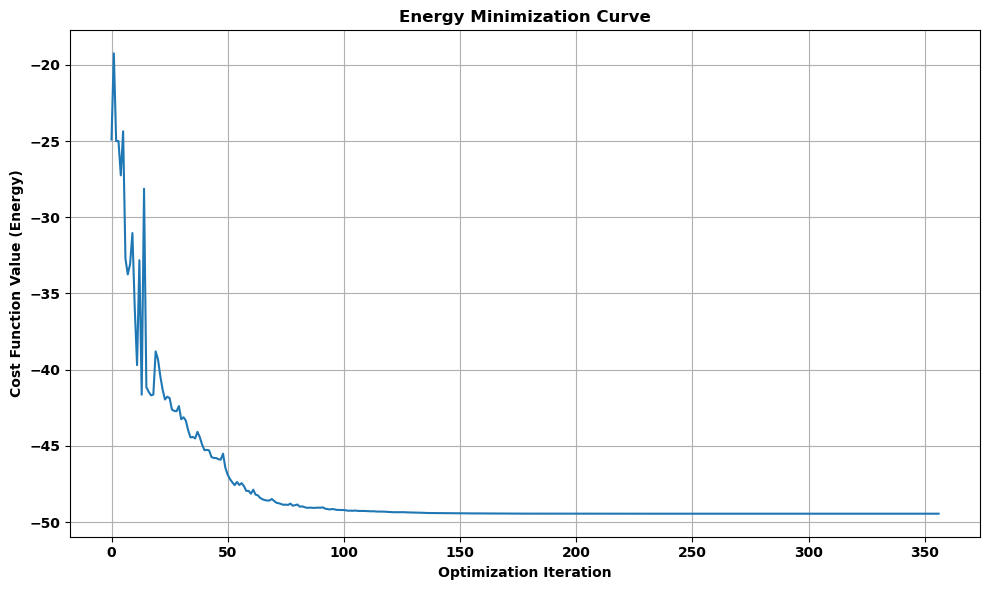

The counts are: {'00': 682, '10': 342}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:376: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


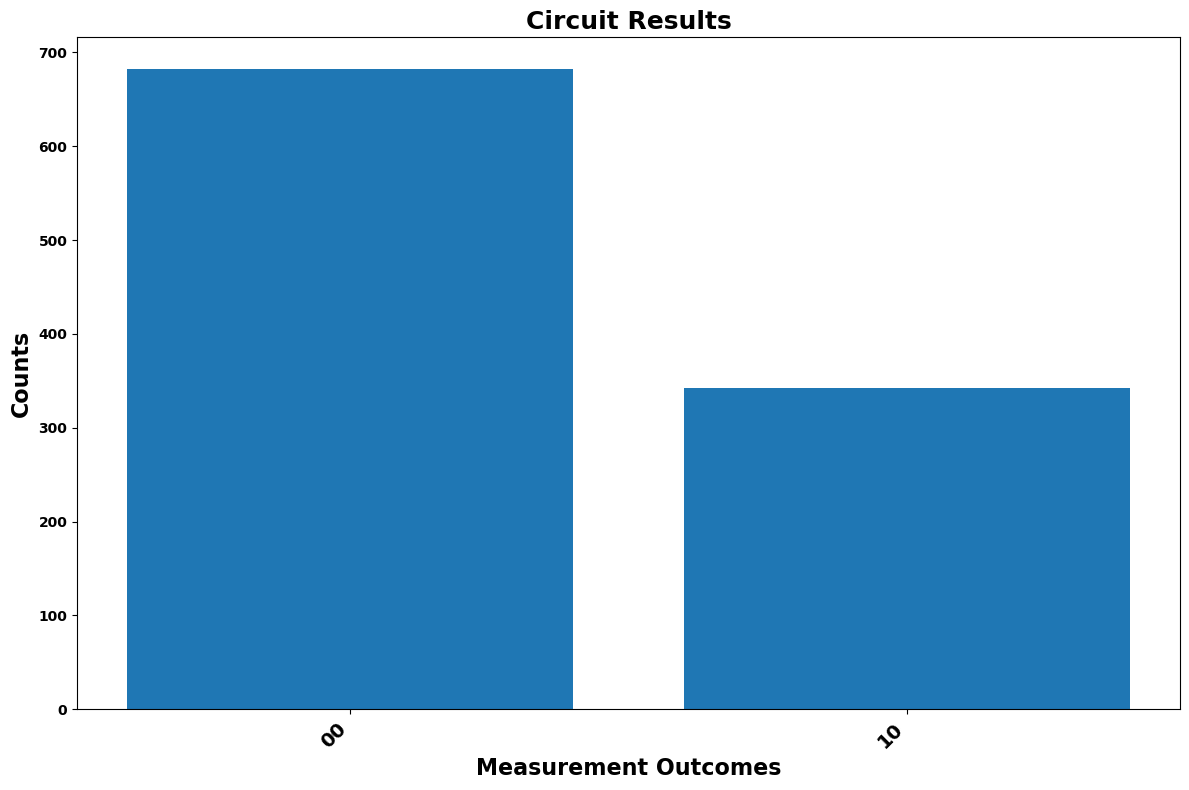

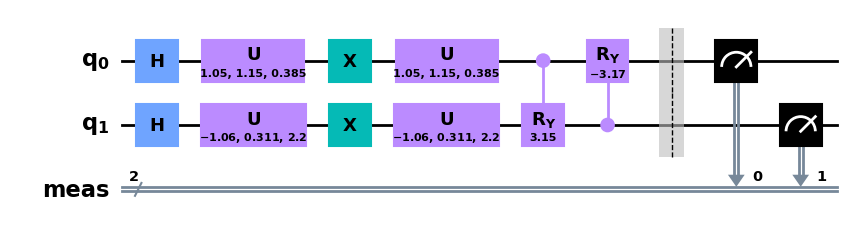

In [20]:
min_ones = 0

result_interaction_bfgs, optimized_full_params_ct1_mo, cost_values = vqe_solver(
    joint_counts_ct1_mo,
    ansatz_grn_ct1_mo, # Renamed from 'cirquit' for common convention
    ct1_percentages_mo, # Renamed from 'act_percentages' for consistency with create_parameter_dictionaries_cust
    cost_func_wrapper, # This function needs to be defined to accept the correct arguments (see comments below)
    min_ones_obs=min_ones, # Added as an explicit argument for flexibility
    optimizer_method="COBYLA",# COBYLA | L-BFGS-B
)

# Plot the cost function values
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
plt.show()
counts, bound_circuit = evaluate_and_plot_ansatz(ansatz_grn_ct1_mo, optimized_full_params_ct1_mo, shots=1024, title="Circuit Results")
bound_circuit.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

Interaction observable CT from histogram: SparsePauliOp(['II', 'IZ', 'ZI', 'ZZ'],
              coeffs=[-25.        +0.j,   0.90634441+0.j,  -4.00302115+0.j,  -2.11480363+0.j])
Static Parameters: {Parameter(ct2_act_0): 1.319279090178191, Parameter(ct2_act_1): 1.627743625651509}
Variable Parameters: {Parameter(ct2_grn_0_1): 0.0, Parameter(ct2_grn_1_0): 0.0, Parameter(ct2_post_acti2_0): 0.0, Parameter(ct2_post_acti2_1): 0.0, Parameter(ct2_post_acti_0): 0.0, Parameter(ct2_post_acti_1): 0.0}
Starting optimization with method: COBYLA
Iteration 0: Current cost: -24.205559870838453
Iteration 20: Current cost: -28.063577120507894
Iteration 40: Current cost: -28.358182270891973
Iteration 60: Current cost: -28.38801132733056
Iteration 80: Current cost: -28.404628211383347
Iteration 100: Current cost: -28.41400419618284
Iteration 200: Current cost: -28.435323086315744
Iteration 300: Current cost: -28.449096975202988
Iteration 400: Current cost: -28.45716602987747
Iteration 500: Current cost: -28.

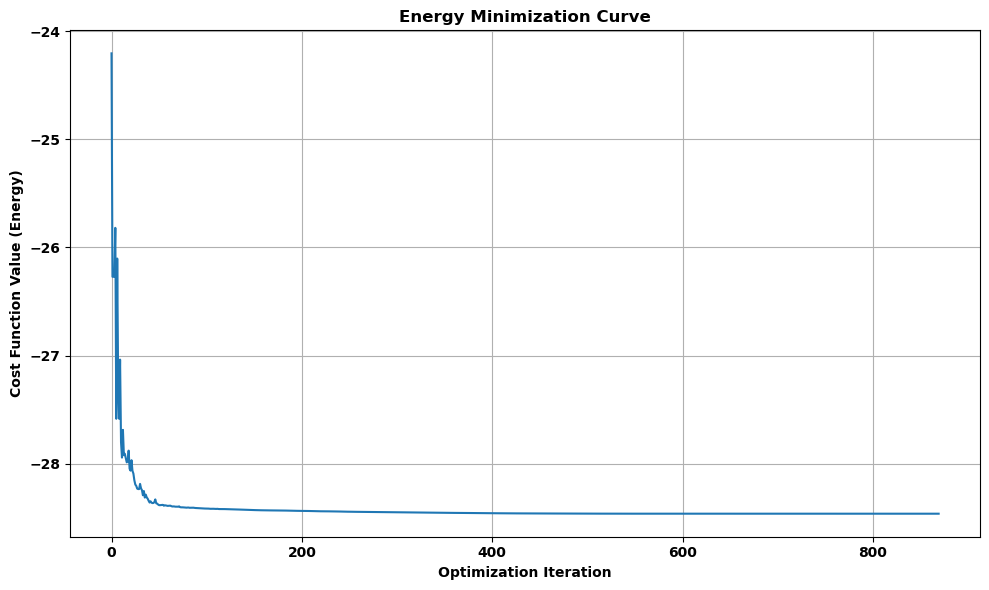

The counts are: {'11': 139, '00': 572, '01': 301, '10': 12}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:376: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


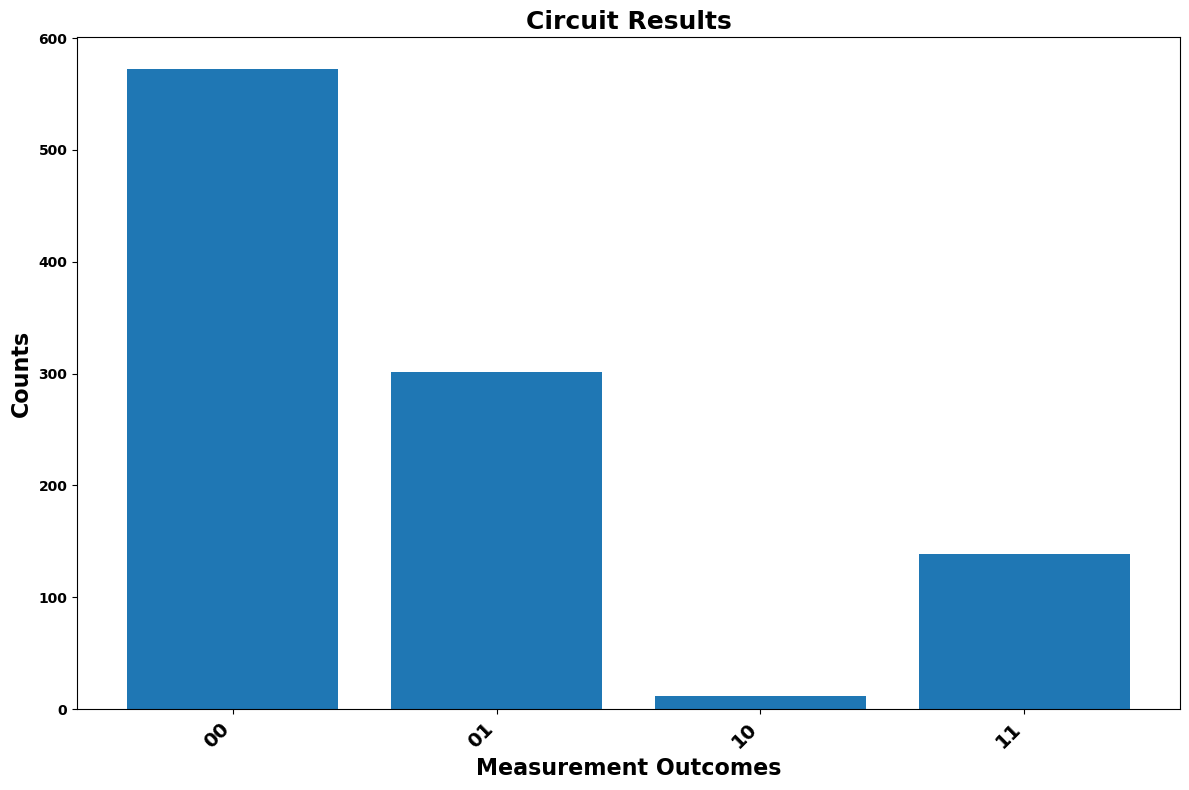

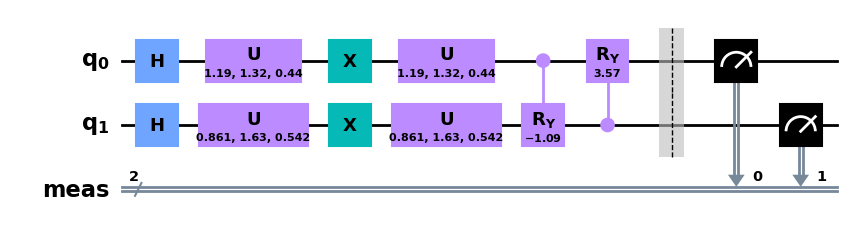

In [21]:
min_ones = 0

result_interaction_bfgs, optimized_full_params_ct2_co, cost_values = vqe_solver(
    joint_counts_ct2_co,
    ansatz_grn_ct2_co, # Renamed from 'cirquit' for common convention
    ct2_percentages_co, # Renamed from 'act_percentages' for consistency with create_parameter_dictionaries_cust
    cost_func_wrapper, # This function needs to be defined to accept the correct arguments (see comments below)
    min_ones_obs=min_ones, # Added as an explicit argument for flexibility
    optimizer_method="COBYLA",# COBYLA | L-BFGS-B
)

# Plot the cost function values
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
plt.show()
counts, bound_circuit = evaluate_and_plot_ansatz(ansatz_grn_ct2_co, optimized_full_params_ct2_co, shots=1024, title="Circuit Results")
bound_circuit.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

Interaction observable CT from histogram: SparsePauliOp(['II', 'IZ', 'ZI', 'ZZ'],
              coeffs=[-25.        +0.j,  -3.51506456+0.j, -10.40172166+0.j,  -2.83357245+0.j])
Static Parameters: {Parameter(ct2_act_0): 0.9172368794914246, Parameter(ct2_act_1): 1.3499383066716542}
Variable Parameters: {Parameter(ct2_grn_0_1): 0.0, Parameter(ct2_grn_1_0): 0.0, Parameter(ct2_post_acti2_0): 0.0, Parameter(ct2_post_acti2_1): 0.0, Parameter(ct2_post_acti_0): 0.0, Parameter(ct2_post_acti_1): 0.0}
Starting optimization with method: COBYLA
Iteration 0: Current cost: -21.815811015163806
Iteration 20: Current cost: -31.609127282595324
Iteration 40: Current cost: -31.96655665649829
Iteration 60: Current cost: -31.999292185820202
Iteration 80: Current cost: -32.00040565585836
Iteration 100: Current cost: -32.00088174724743
Iteration 200: Current cost: -32.00188805729677
Iteration 300: Current cost: -32.002294108617996
Iteration 400: Current cost: -32.00254451093903
Iteration 500: Current cost: -32.

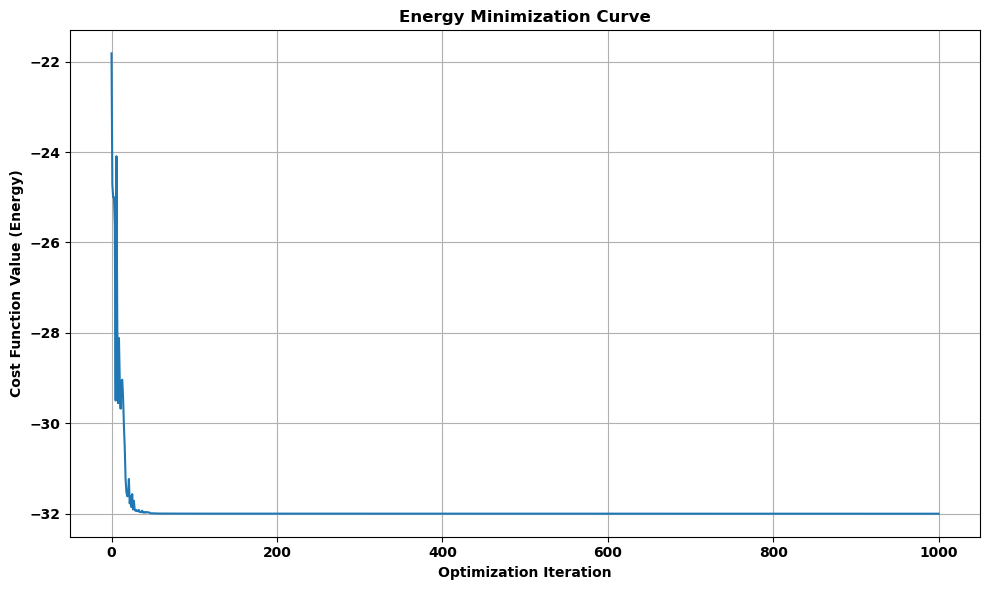

The counts are: {'00': 427, '01': 380, '10': 198, '11': 19}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:376: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


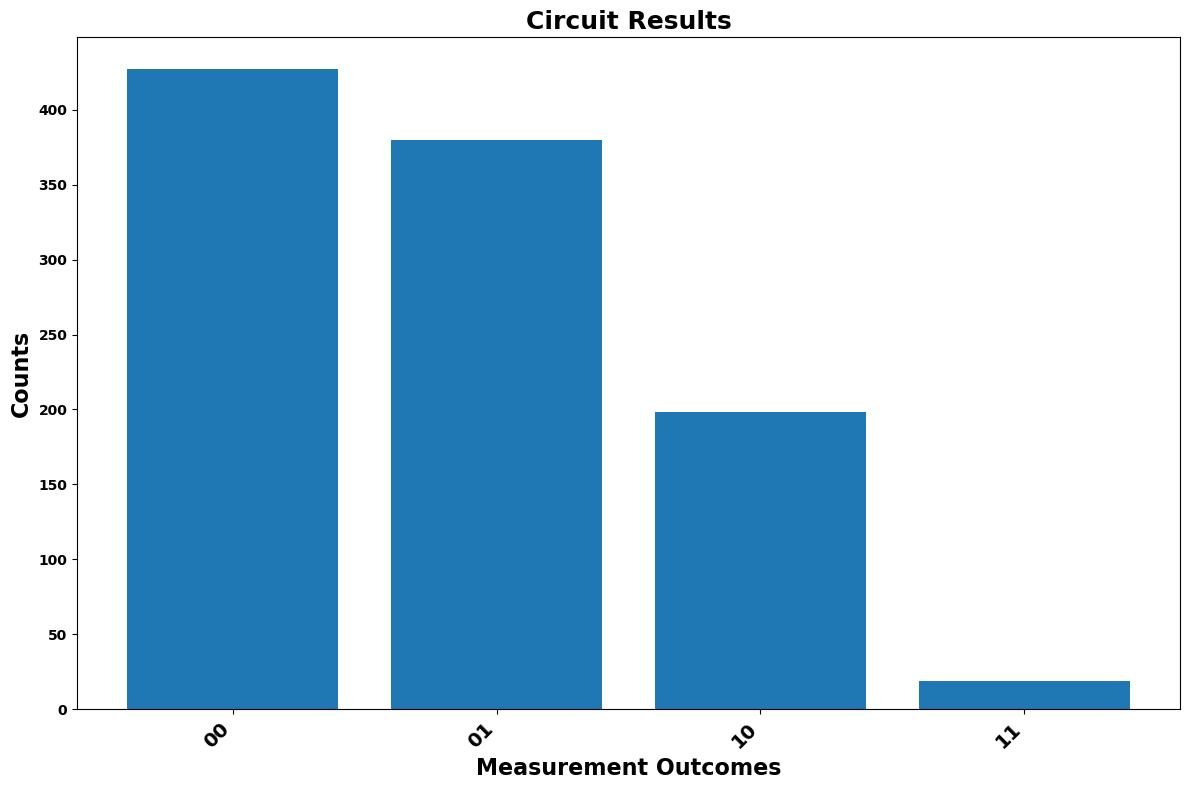

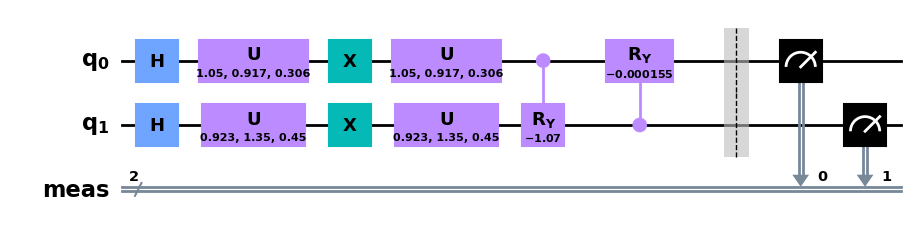

In [22]:
min_ones = 0

result_interaction_bfgs, optimized_full_params_ct2_mo, cost_values = vqe_solver(
    joint_counts_ct2_mo,
    ansatz_grn_ct2_mo, # Renamed from 'cirquit' for common convention
    ct2_percentages_mo, # Renamed from 'act_percentages' for consistency with create_parameter_dictionaries_cust
    cost_func_wrapper, # This function needs to be defined to accept the correct arguments (see comments below)
    min_ones_obs=min_ones, # Added as an explicit argument for flexibility
    optimizer_method="COBYLA",# COBYLA | L-BFGS-B
)

# Plot the cost function values
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
plt.show()
counts, bound_circuit = evaluate_and_plot_ansatz(ansatz_grn_ct2_mo, optimized_full_params_ct2_mo, shots=1024, title="Circuit Results")
bound_circuit.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

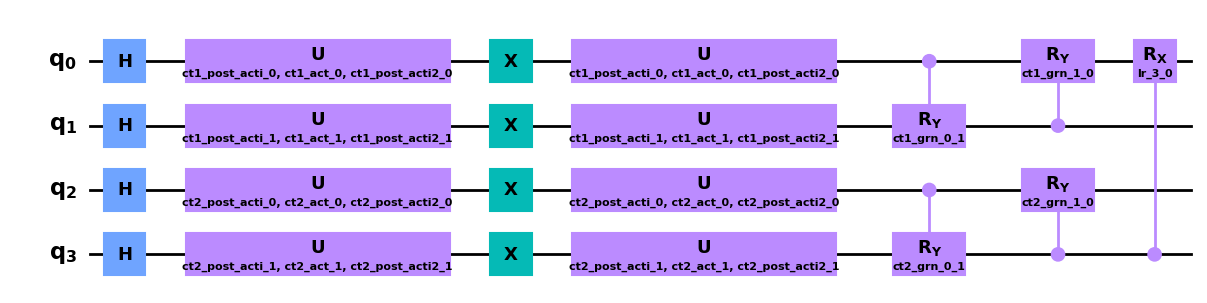

In [23]:
interactions_lr = {
    (ng_ct1 + ng_ct2 - 1, 0): 10,
}
cc_grn_circuit_co = create_joint_circuit_from_ansatzes(ansatz_grn_ct1_co, ansatz_grn_ct2_co, interactions = interactions_lr)
cc_grn_circuit_mo = create_joint_circuit_from_ansatzes(ansatz_grn_ct1_mo, ansatz_grn_ct2_mo, interactions = interactions_lr)
cc_grn_circuit_mo.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

{Parameter(ct1_act_0): 1.1775418008504883, Parameter(ct1_act_1): 0.9398116636976538, Parameter(ct1_grn_0_1): -0.5337228864902773, Parameter(ct1_grn_1_0): -1.1507931397086821, Parameter(ct1_post_acti2_0): 0.39118416633125475, Parameter(ct1_post_acti2_1): 2.3841555179927716, Parameter(ct1_post_acti_0): 1.0535671154242465, Parameter(ct1_post_acti_1): -1.1283354904844998, Parameter(ct2_act_0): 1.319279090178191, Parameter(ct2_act_1): 1.627743625651509, Parameter(ct2_grn_0_1): -1.0872752562683095, Parameter(ct2_grn_1_0): 3.566286936578909, Parameter(ct2_post_acti2_0): 0.4395383879033369, Parameter(ct2_post_acti2_1): 0.5424685129867723, Parameter(ct2_post_acti_0): 1.1887576051668813, Parameter(ct2_post_acti_1): 0.8608335355404786, Parameter(lr_3_0): 0.0}
Interaction observable LR custom:  SparsePauliOp(['ZIIZ'],
              coeffs=[-10.+0.j])
  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: -4.237501310535037
        x: [-2.474e+00]
      

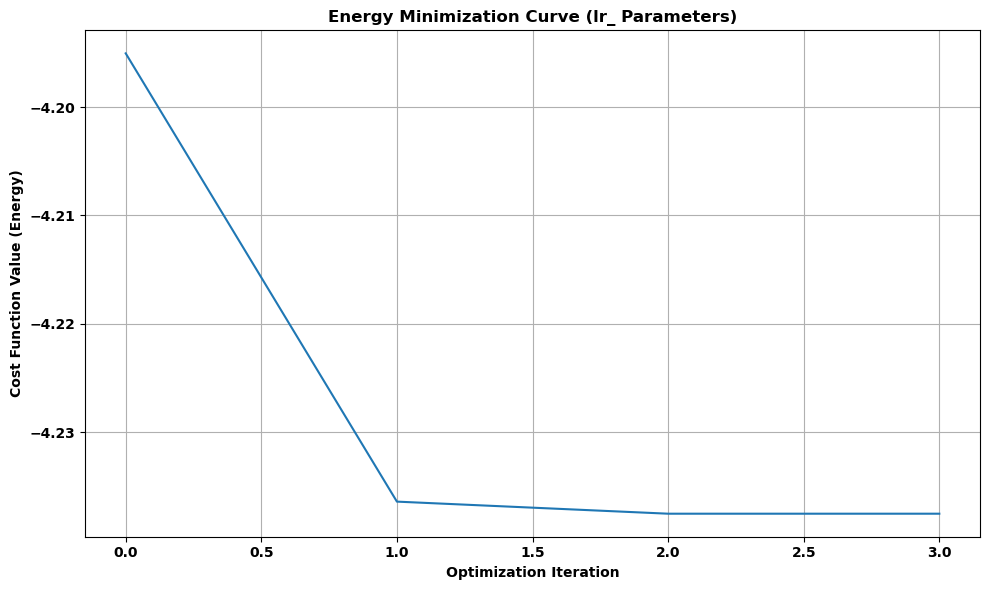

In [24]:
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector
from quantum_functions import create_interaction_observable_general

estimator = StatevectorEstimator()

# --- 1. Create Static Parameter Dictionaries ---
static_params_lr, variable_params_lr = create_parameter_dictionaries_from_circuit(cc_grn_circuit_co)

# Update static_params_lr with values from all_params and all_params2
for param in static_params_lr:
    if param.name in [p.name for p in optimized_full_params_ct1_co]:
        # Access value directly by name
        static_params_lr[param] = optimized_full_params_ct1_co[next(p for p in optimized_full_params_ct1_co if p.name == param.name)]
    elif param.name in [p.name for p in optimized_full_params_ct2_co]:
        # Access value directly by name
        static_params_lr[param] = optimized_full_params_ct2_co[next(p for p in optimized_full_params_ct2_co if p.name == param.name)]

x0_lr = np.zeros(len(variable_params_lr))  # Initial lr_ values

# Create the combined parameter dictionary.
all_params_lr_co = static_params_lr.copy()
all_params_lr_co.update(dict(zip(variable_params_lr, x0_lr)))

print(all_params_lr_co)


interaction_observable_lr_co = create_interaction_observable_general(interactions_lr, ng_ct1 + ng_ct2)
print("Interaction observable LR custom: ", interaction_observable_lr_co)

cost_values = []
result_lr_bfgs = minimize(
    cost_func_wrapper, 
    x0_lr,
    args=(all_params_lr_co, cc_grn_circuit_co, interaction_observable_lr_co, estimator, variable_params_lr),  # Correct args
    method="L-BFGS-B",
    callback=lambda xk: cost_values.append(cost_func_wrapper(xk, all_params_lr_co, cc_grn_circuit_co, interaction_observable_lr_co, estimator, variable_params_lr))  # Correct callback
)

print(result_lr_bfgs)

# --- 6. Results and DataFrame ---
optimized_lr_values = result_lr_bfgs.x

# Update the lr_ parameters in the combined dictionary (optional)
all_params_lr_co.update(dict(zip(variable_params_lr, optimized_lr_values)))

# --- 7. Plotting ---
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve (lr_ Parameters)")
plt.grid(True)
plt.tight_layout()
plt.show()


{Parameter(ct1_act_0): 1.1548409543018316, Parameter(ct1_act_1): 0.31096983119289834, Parameter(ct1_grn_0_1): 3.153180379949362, Parameter(ct1_grn_1_0): -3.1745182468069335, Parameter(ct1_post_acti2_0): 0.3850970601942069, Parameter(ct1_post_acti2_1): 2.1969009676705586, Parameter(ct1_post_acti_0): 1.047639242263721, Parameter(ct1_post_acti_1): -1.0553465991969795, Parameter(ct2_act_0): 0.9172368794914246, Parameter(ct2_act_1): 1.3499383066716542, Parameter(ct2_grn_0_1): -1.0744522770437024, Parameter(ct2_grn_1_0): -0.00015534009533935865, Parameter(ct2_post_acti2_0): 0.3057375599306027, Parameter(ct2_post_acti2_1): 0.44995192592009947, Parameter(ct2_post_acti_0): 1.04709781641476, Parameter(ct2_post_acti_1): 0.9225293681186618, Parameter(lr_3_0): 0.0}
Interaction observable LR custom:  SparsePauliOp(['ZIIZ'],
              coeffs=[-10.+0.j])
  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: -9.997763873891852
        x: [-3.120e+00]
  

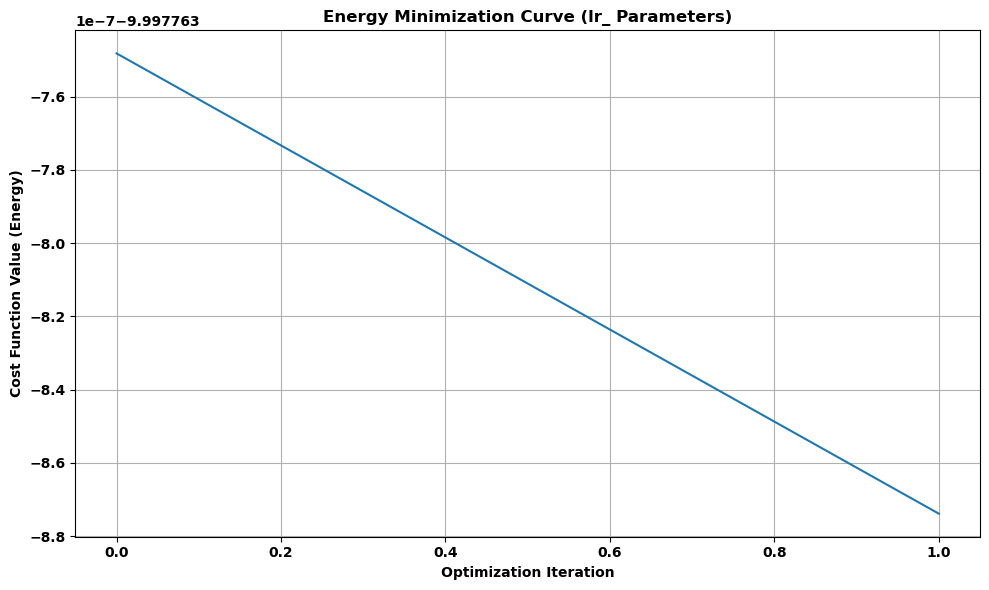

In [25]:
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector

estimator = StatevectorEstimator()

# --- 1. Create Static Parameter Dictionaries ---
static_params_lr, variable_params_lr = create_parameter_dictionaries_from_circuit(cc_grn_circuit_mo)

# Update static_params_lr with values from all_params and all_params2
for param in static_params_lr:
    if param.name in [p.name for p in optimized_full_params_ct1_mo]:
        # Access value directly by name
        static_params_lr[param] = optimized_full_params_ct1_mo[next(p for p in optimized_full_params_ct1_mo if p.name == param.name)]
    elif param.name in [p.name for p in optimized_full_params_ct2_mo]:
        # Access value directly by name
        static_params_lr[param] = optimized_full_params_ct2_mo[next(p for p in optimized_full_params_ct2_mo if p.name == param.name)]



x0_lr = np.zeros(len(variable_params_lr))  # Initial lr_ values

# Create the combined parameter dictionary.
all_params_lr_mo = static_params_lr.copy()
all_params_lr_mo.update(dict(zip(variable_params_lr, x0_lr)))

print(all_params_lr_mo)

interaction_observable_lr_mo = create_interaction_observable_general(interactions_lr, ng_ct1 + ng_ct2)
print("Interaction observable LR custom: ", interaction_observable_lr_mo)

cost_values = []
result_lr_bfgs = minimize(
    cost_func_wrapper, 
    x0_lr,
    args=(all_params_lr_mo, cc_grn_circuit_mo, interaction_observable_lr_mo, estimator, variable_params_lr),  # Correct args
    method="L-BFGS-B",
    callback=lambda xk: cost_values.append(cost_func_wrapper(xk, all_params_lr_mo, cc_grn_circuit_mo, interaction_observable_lr_mo, estimator, variable_params_lr))  # Correct callback
)

print(result_lr_bfgs)

# --- 6. Results and DataFrame ---
optimized_lr_values = result_lr_bfgs.x

# Update the lr_ parameters in the combined dictionary (optional)
all_params_lr_mo.update(dict(zip(variable_params_lr, optimized_lr_values)))

# --- 7. Plotting ---
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve (lr_ Parameters)")
plt.grid(True)
plt.tight_layout()
plt.show()

The counts are: {'0000': 340, '0101': 82, '1101': 133, '0001': 170, '0100': 166, '0010': 43, '0011': 4, '1111': 8, '1100': 32, '0110': 28, '0111': 2, '1110': 7, '1001': 6, '1000': 3}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:376: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


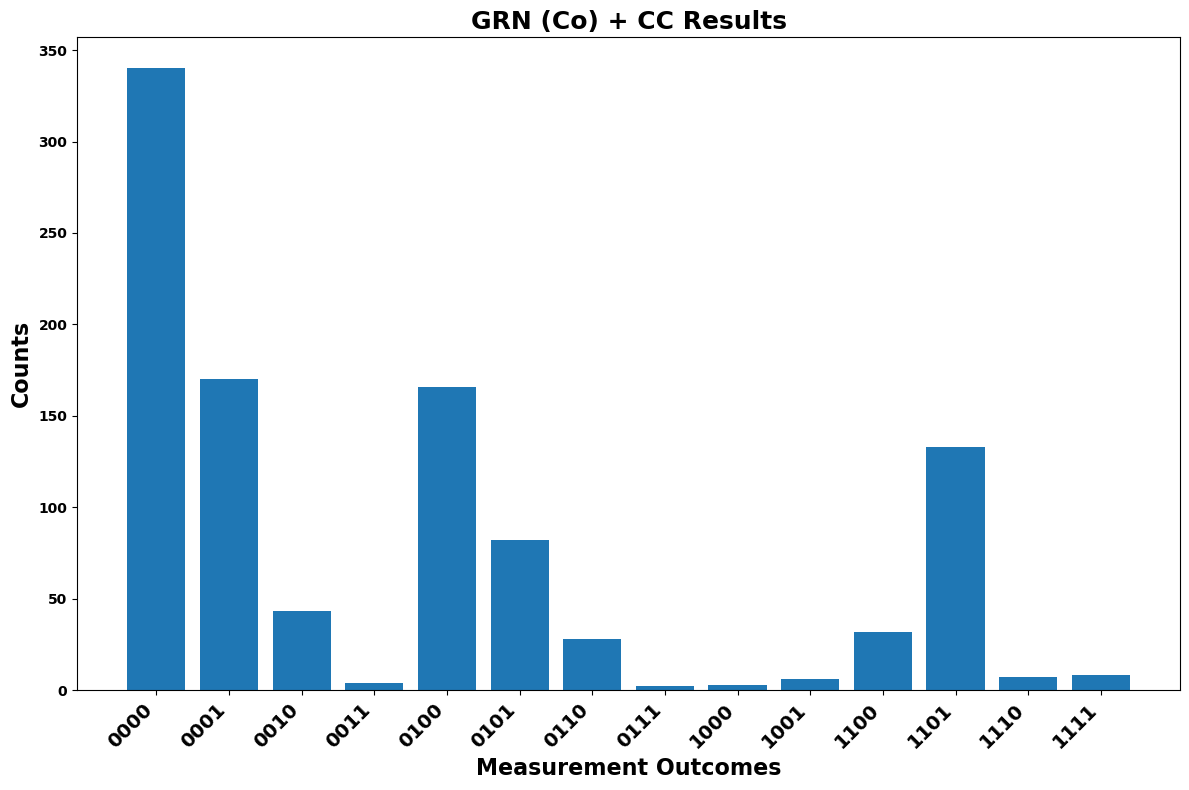

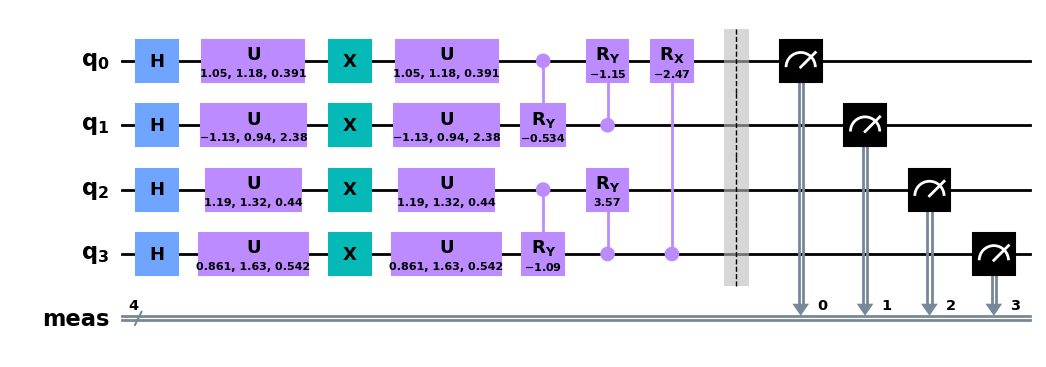

In [26]:
counts_cc_grn_co, bound_circuit_cc_grn_co = evaluate_and_plot_ansatz(cc_grn_circuit_co, all_params_lr_co, shots=1024, title="GRN (Co) + CC Results")
bound_circuit_cc_grn_co.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

The counts are: {'0110': 128, '1001': 132, '0000': 289, '1011': 54, '0100': 257, '0010': 141, '1101': 17, '1111': 6}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:376: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


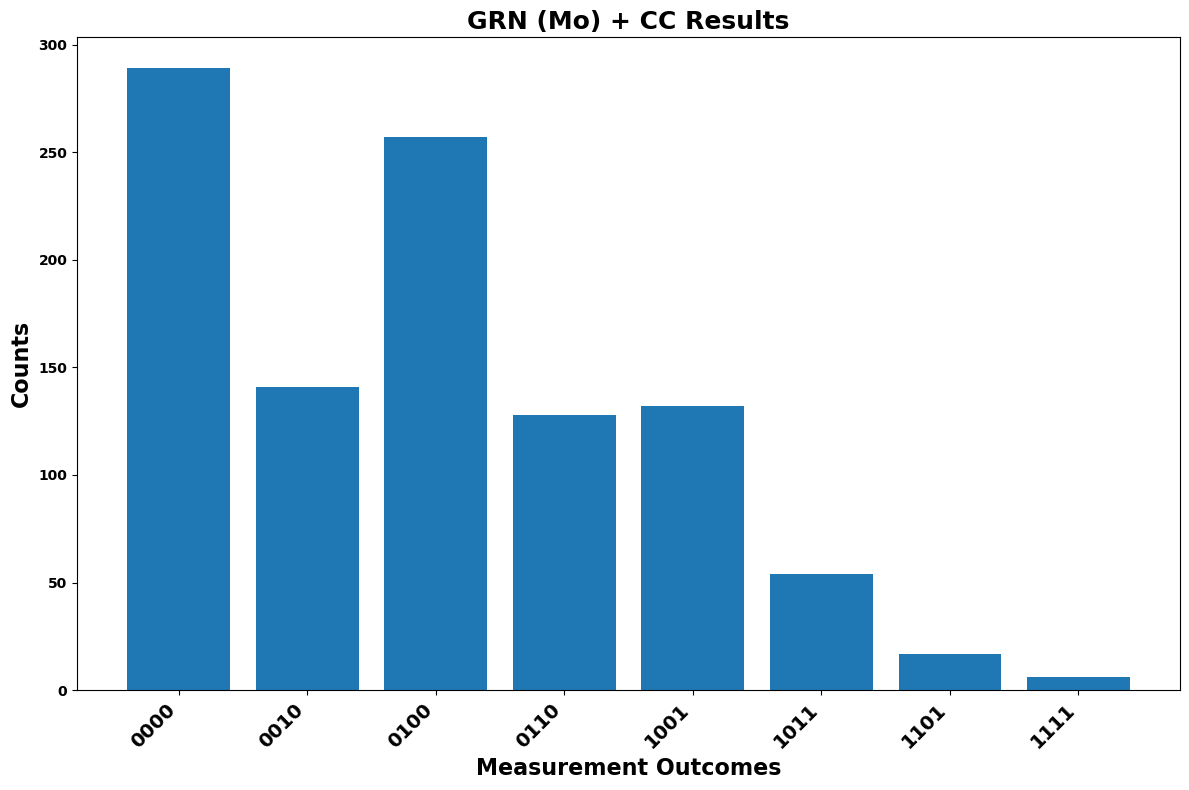

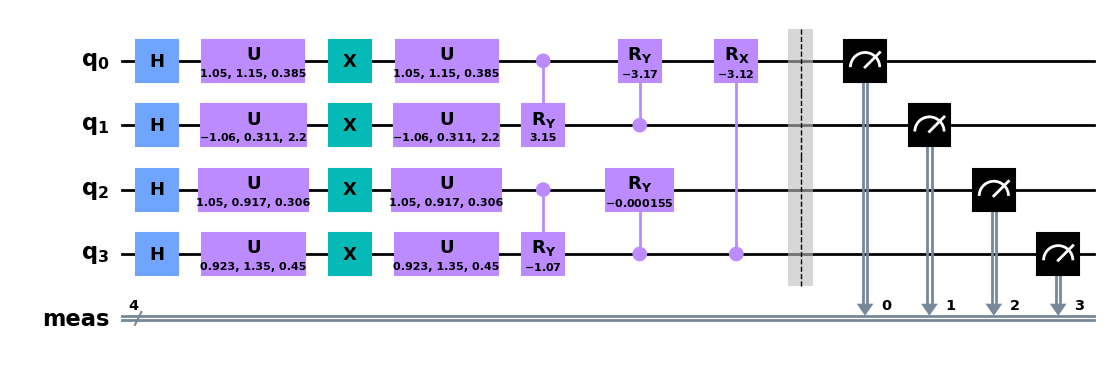

In [27]:
counts_cc_grn_mo, bound_circuit_cc_grn_mo = evaluate_and_plot_ansatz(cc_grn_circuit_mo, all_params_lr_mo, shots=1024, title="GRN (Mo) + CC Results")
bound_circuit_cc_grn_mo.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

In [28]:
interactions_lr = {
    (ng_ct1-1, ng_ct1): 0,
}

cc_grn_circuit_co0 = create_circuit_lr2(ansatz_grn_ct1_co, ansatz_grn_ct2_co, interactions = interactions_lr)
cc_grn_circuit_mo0 = create_circuit_lr2(ansatz_grn_ct1_mo, ansatz_grn_ct2_mo, interactions = interactions_lr)
cc_grn_circuit_mo0.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

NameError: name 'create_circuit_lr2' is not defined

{Parameter(ct1_act_0): 2.3550836017009766, Parameter(ct1_act_1): 1.8796233273953076, Parameter(ct1_grn_0_1): 1.7406934551627438, Parameter(ct1_grn_1_0): -0.9824013537481802, Parameter(ct2_act_0): 2.638558180356382, Parameter(ct2_act_1): 3.255487251303018, Parameter(ct2_grn_0_1): -1.563063218529657, Parameter(ct2_grn_1_0): 1.964329339688475, Parameter(lr_1_2): 0.0}
Interaction observable LR custom:  SparsePauliOp(['IZZI'],
              coeffs=[0.+0.j])
  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 0.0
        x: [ 0.000e+00]
      nit: 0
      jac: [ 0.000e+00]
     nfev: 2
     njev: 1
 hess_inv: <1x1 LbfgsInvHessProduct with dtype=float64>


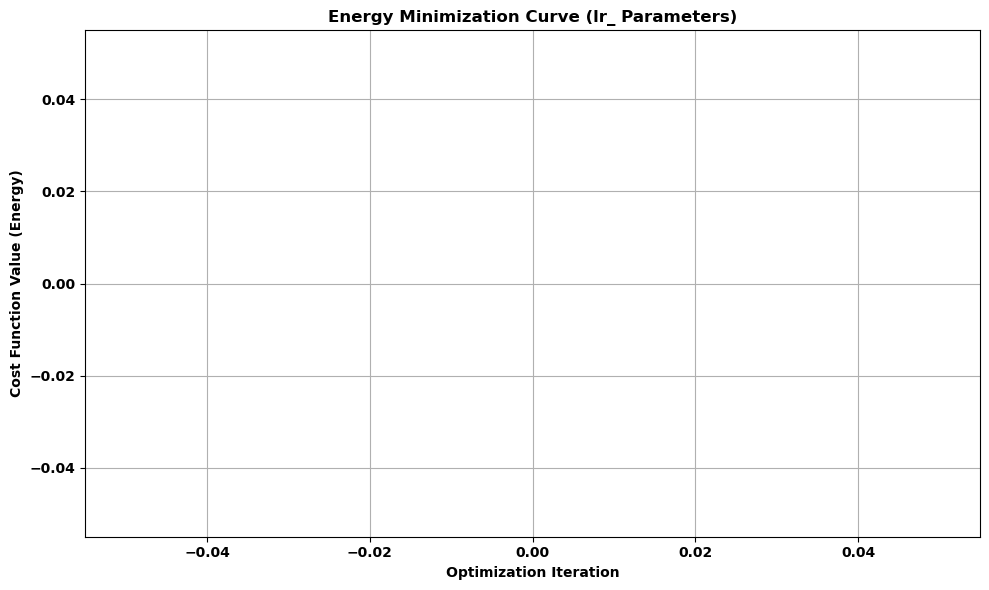

In [ ]:
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector

estimator = StatevectorEstimator()

# --- 1. Create Static Parameter Dictionaries ---
static_params_lr, variable_params_lr = create_parameter_dictionaries_from_circuit(cc_grn_circuit_co0)

# Update static_params_lr with values from all_params and all_params2
for param in static_params_lr:
    if param.name in [p.name for p in all_params_ct1_co]:
        # Access value directly by name
        static_params_lr[param] = all_params_ct1_co[next(p for p in all_params_ct1_co if p.name == param.name)]
    elif param.name in [p.name for p in all_params_ct2_co]:
        # Access value directly by name
        static_params_lr[param] = all_params_ct2_co[next(p for p in all_params_ct2_co if p.name == param.name)]
        
x0_lr = np.zeros(len(variable_params_lr))  # Initial lr_ values

# Create the combined parameter dictionary.
all_params_lr_co0 = static_params_lr.copy()
all_params_lr_co0.update(dict(zip(variable_params_lr, x0_lr)))

print(all_params_lr_co0)

interaction_observable_lr_co = create_interaction_observable_general(interactions_lr, ng_ct1 + ng_ct2)
print("Interaction observable LR custom: ", interaction_observable_lr_co)

cost_values = []
result_lr_bfgs = minimize(
    cost_func_wrapper, 
    x0_lr,
    args=(all_params_lr_co0, cc_grn_circuit_co0, interaction_observable_lr_co, estimator, variable_params_lr),  # Correct args
    method="L-BFGS-B",
    callback=lambda xk: cost_values.append(cost_func_wrapper(xk, all_params_lr_co0, cc_grn_circuit_co0, interaction_observable_lr_co, estimator, variable_params_lr))  # Correct callback
)

print(result_lr_bfgs)

# --- 6. Results and DataFrame ---
optimized_lr_values = result_lr_bfgs.x

# Update the lr_ parameters in the combined dictionary (optional)
all_params_lr_co0.update(dict(zip(variable_params_lr, optimized_lr_values)))

# --- 7. Plotting ---
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve (lr_ Parameters)")
plt.grid(True)
plt.tight_layout()
plt.show()


{Parameter(ct1_act_0): 2.3096819086036633, Parameter(ct1_act_1): 0.6219396623857967, Parameter(ct1_grn_0_1): -1.5663485134370587, Parameter(ct1_grn_1_0): 0.7711444742525265, Parameter(ct2_act_0): 1.8344737589828493, Parameter(ct2_act_1): 2.6998766133433083, Parameter(ct2_grn_0_1): -1.720941203486042, Parameter(ct2_grn_1_0): 2.164982518430156, Parameter(lr_1_2): 0.0}
Interaction observable LR custom:  SparsePauliOp(['IZZI'],
              coeffs=[0.+0.j])
  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 0.0
        x: [ 0.000e+00]
      nit: 0
      jac: [ 0.000e+00]
     nfev: 2
     njev: 1
 hess_inv: <1x1 LbfgsInvHessProduct with dtype=float64>


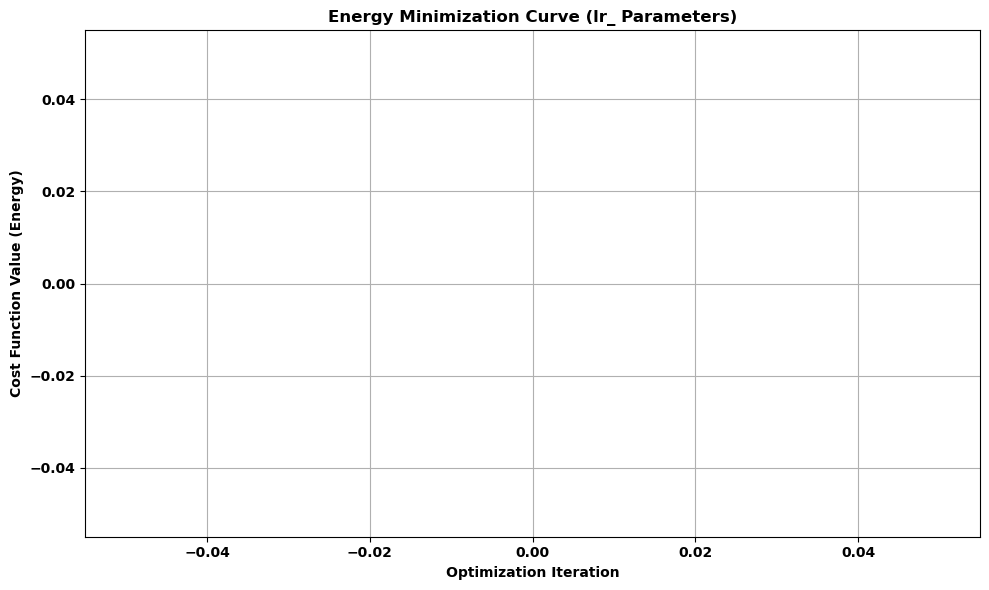

In [ ]:
from qiskit.primitives import StatevectorEstimator
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector

estimator = StatevectorEstimator()

# --- 1. Create Static Parameter Dictionaries ---
static_params_lr, variable_params_lr = create_parameter_dictionaries_from_circuit(cc_grn_circuit_mo0)

# Update static_params_lr with values from all_params and all_params2
for param in static_params_lr:
    if param.name in [p.name for p in all_params_ct1_mo]:
        # Access value directly by name
        static_params_lr[param] = all_params_ct1_mo[next(p for p in all_params_ct1_mo if p.name == param.name)]
    elif param.name in [p.name for p in all_params_ct2_mo]:
        # Access value directly by name
        static_params_lr[param] = all_params_ct2_mo[next(p for p in all_params_ct2_mo if p.name == param.name)]

x0_lr = np.zeros(len(variable_params_lr))  # Initial lr_ values

# Create the combined parameter dictionary.
all_params_lr_mo0 = static_params_lr.copy()
all_params_lr_mo0.update(dict(zip(variable_params_lr, x0_lr)))

print(all_params_lr_mo0)

interaction_observable_lr_mo = create_interaction_observable_general(interactions_lr, ng_ct1 + ng_ct2)
print("Interaction observable LR custom: ", interaction_observable_lr_mo)

cost_values = []
result_lr_bfgs = minimize(
    cost_func_wrapper, 
    x0_lr,
    args=(all_params_lr_mo0, cc_grn_circuit_mo0, interaction_observable_lr_mo, estimator, variable_params_lr),  # Correct args
    method="L-BFGS-B",
    callback=lambda xk: cost_values.append(cost_func_wrapper(xk, all_params_lr_mo0, cc_grn_circuit_mo0, interaction_observable_lr_mo, estimator, variable_params_lr))  # Correct callback
)

print(result_lr_bfgs)

# --- 6. Results and DataFrame ---
optimized_lr_values = result_lr_bfgs.x

# Update the lr_ parameters in the combined dictionary (optional)
all_params_lr_mo0.update(dict(zip(variable_params_lr, optimized_lr_values)))

# --- 7. Plotting ---
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve (lr_ Parameters)")
plt.grid(True)
plt.tight_layout()
plt.show()

The counts are: {'1000': 166, '1001': 254, '0011': 34, '0001': 84, '1101': 24, '1010': 199, '1011': 101, '0010': 65, '0000': 60, '1110': 15, '1111': 13, '1100': 8, '0111': 1}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:177: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


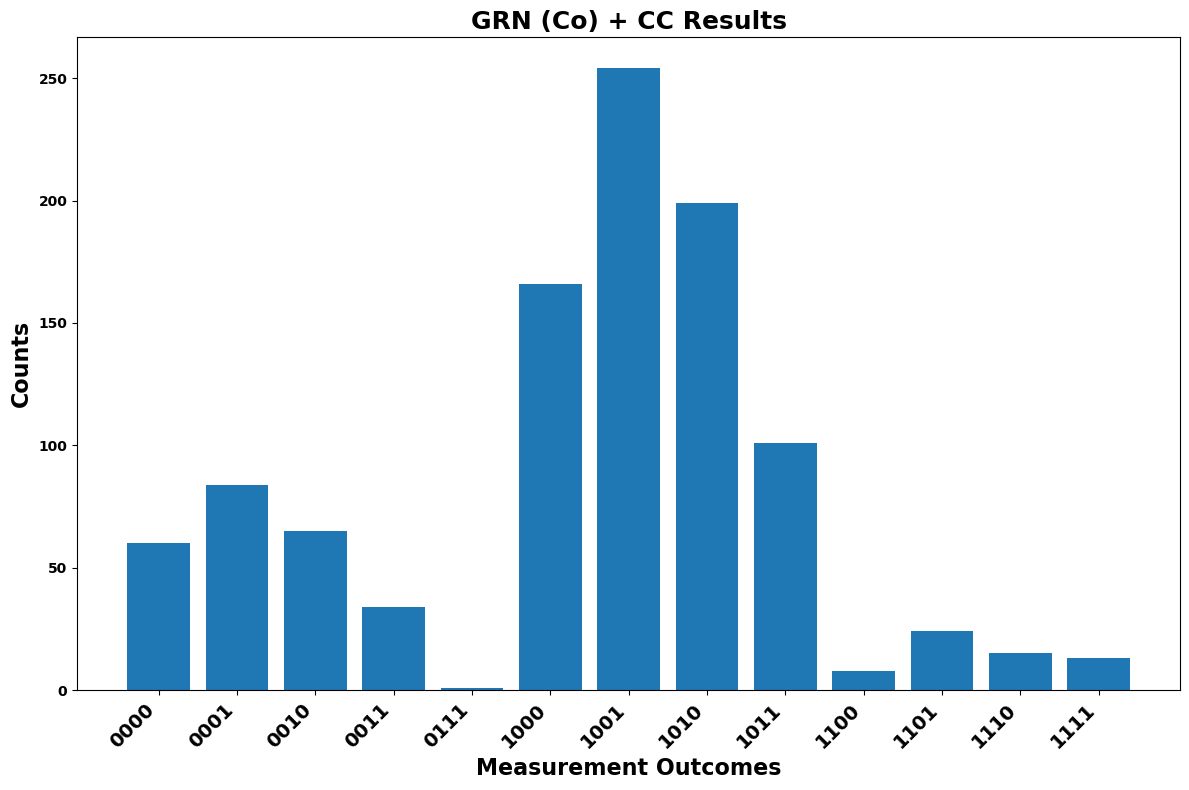

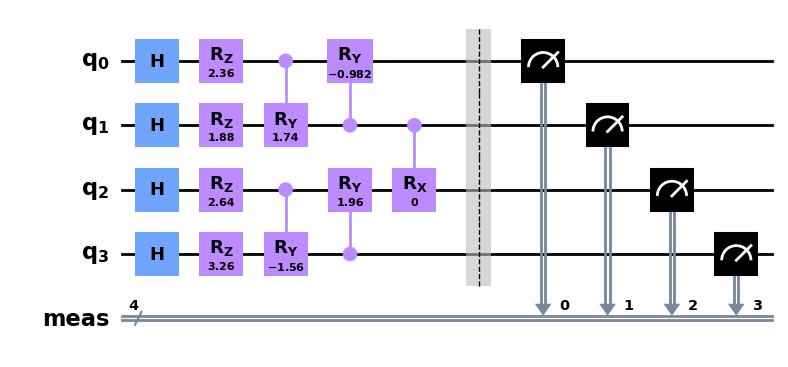

In [ ]:
counts_cc_grn_co0, bound_circuit_cc_grn_co0 = evaluate_and_plot_ansatz(cc_grn_circuit_co0, all_params_lr_co0, shots=1024, title="GRN (Co) + CC Results")
bound_circuit_cc_grn_co0.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

The counts are: {'1001': 274, '0010': 66, '1100': 44, '1010': 170, '0000': 62, '1000': 151, '1110': 40, '0100': 5, '1101': 70, '0001': 115, '0101': 13, '0110': 9, '1011': 3, '0011': 1, '1111': 1}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:177: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


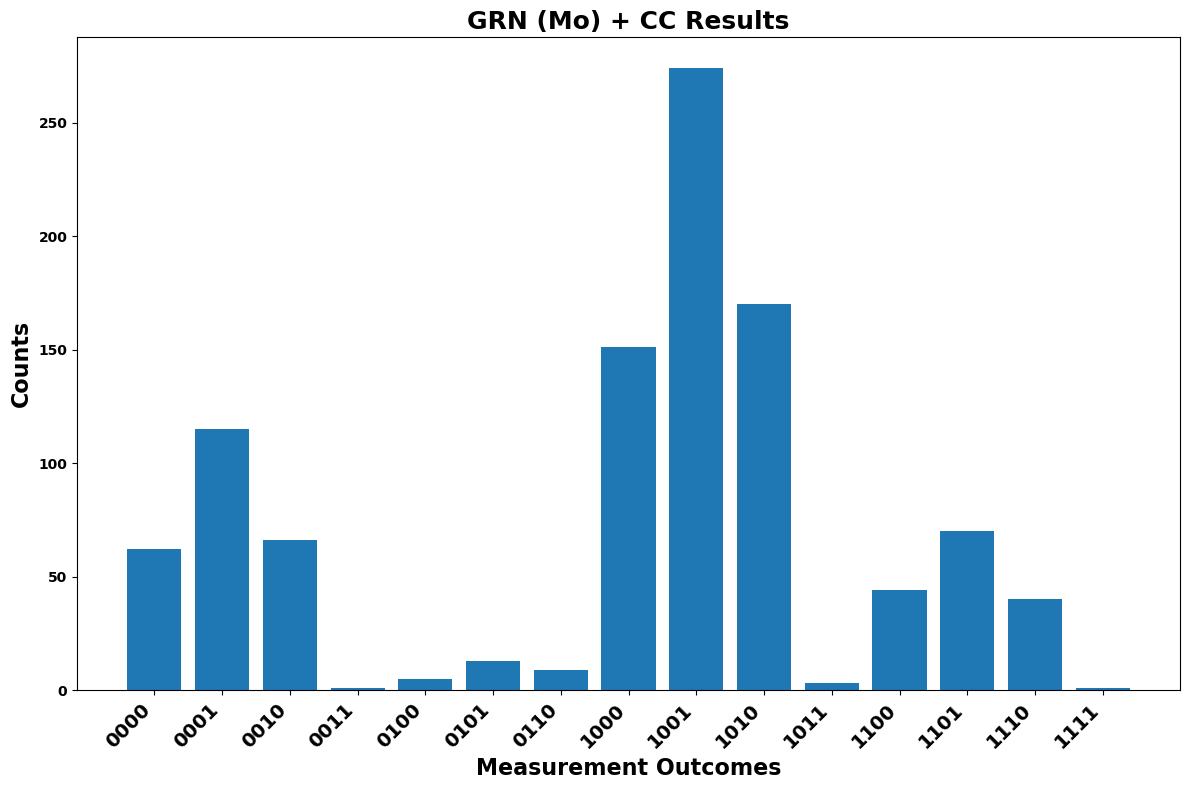

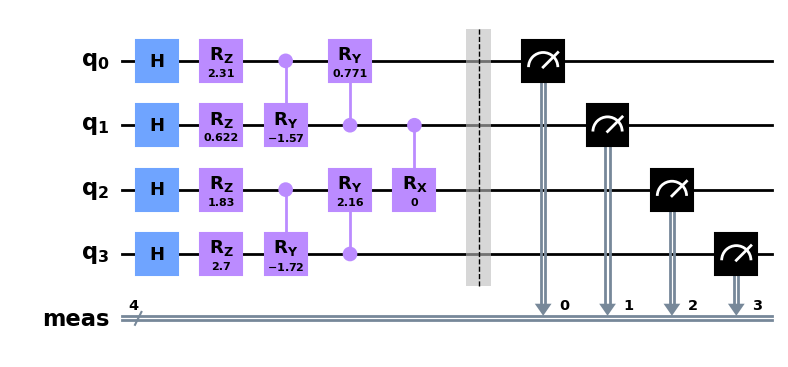

In [ ]:
counts_cc_grn_mo0, bound_circuit_cc_grn_mo0 = evaluate_and_plot_ansatz(cc_grn_circuit_mo0, all_params_lr_mo0, shots=1024, title="GRN (Mo) + CC Results")
bound_circuit_cc_grn_mo0.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

In [ ]:
def filter_bitstrings_from_interactions(interactions_lr, num_qubits):
    """
    Generates bit string patterns based on the given interactions_lr
    for plotting specific bitstring patterns.
    Args:
        interactions_lr (dict): A dictionary representing interactions,
                                 where keys are tuples of qubit indices
                                 and values are interaction strengths.
        num_qubits (int): The total number of qubits in the system.

    Returns:
        list: A list of bit string patterns with '1' at the interacting
              qubit positions and '0' elsewhere.
    """
    patterns = []
    for interaction in interactions_lr:
        pattern = ['.'] * num_qubits
        for qubit_index in interaction:
            if 0 <= qubit_index < num_qubits:
                pattern[num_qubits - 1 - qubit_index] = '1'  # Adjust for bit order
        patterns.append("".join(pattern))
    return patterns

bitstring_patterns = filter_bitstrings_from_interactions(interactions_lr, cc_grn_circuit_co.num_qubits)
print(bitstring_patterns)

['.11.']


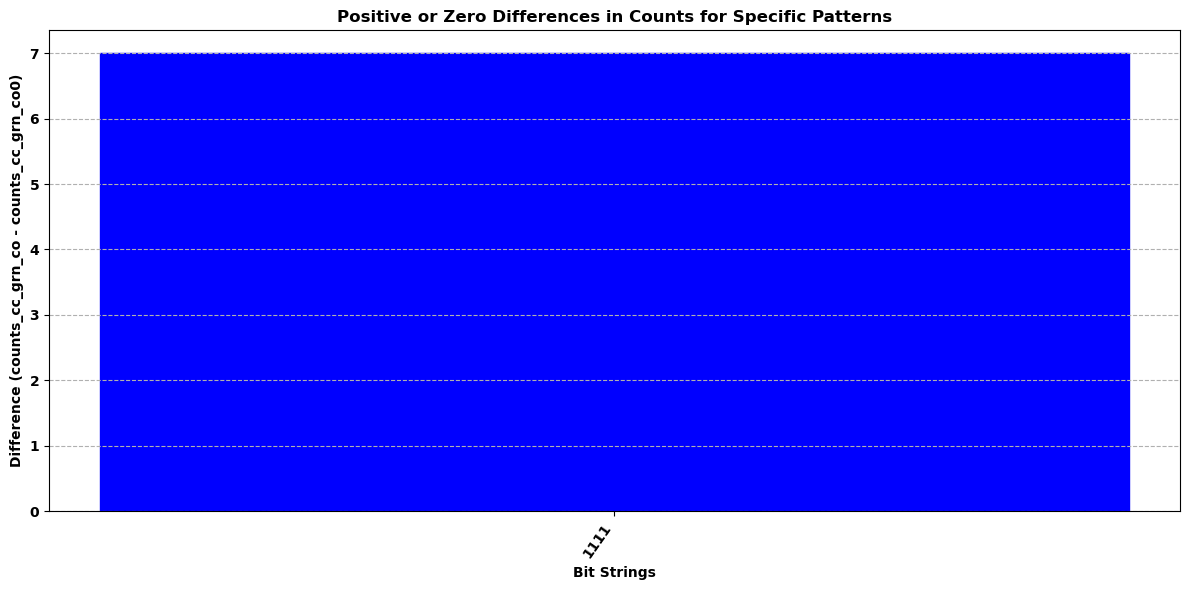

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assume counts_cc_grn_co0 and counts_cc_grn_co are defined dictionaries here.
# Assume bitstring_patterns is a defined list of patterns here.

differences_co = {}

# Calculate the differences, handling cases where bitstrings are not common
all_bitstrings = set(counts_cc_grn_co0.keys()) | set(counts_cc_grn_co.keys())

for key in all_bitstrings:
    count_co0 = counts_cc_grn_co0.get(key, 0)
    count_co = counts_cc_grn_co.get(key, 0)
    differences_co[key] = count_co - count_co0

# Define the pattern matching function
def matches_pattern(bitstring, pattern):
    if len(bitstring) != len(pattern):
        return False
    for i in range(len(bitstring)):
        if pattern[i] != '.' and pattern[i] != bitstring[i]:
            return False
    return True

# Filter bitstrings based on the defined patterns first
pattern_filtered_bitstrings = []
pattern_filtered_differences = []

for bitstring, difference in differences_co.items():
    for pattern in bitstring_patterns:
        if matches_pattern(bitstring, pattern):
            # Keep this bitstring and difference if it matches any pattern
            pattern_filtered_bitstrings.append(bitstring)
            pattern_filtered_differences.append(difference)
            break # Move to the next bitstring once a match is found

# --- Filter for positive or zero differences ONLY ---
# Create new lists containing only the elements where the difference is >= 0
filtered_bitstrings_co = [] # Rename to clarify these are the final filtered lists
filtered_differences_co = []

# Iterate through the pattern-filtered data and keep only positive/zero differences
for bitstring, difference in zip(pattern_filtered_bitstrings, pattern_filtered_differences):
    if difference > 0: # Keep only positive or zero differences
        filtered_bitstrings_co.append(bitstring)
        filtered_differences_co.append(difference)

# --- End of filtering for positive differences ---


# Sort the filtered bitstrings for better visualization
# This sorting now applies only to the bitstrings with positive differences
sorted_indices = np.argsort(filtered_bitstrings_co)
filtered_bitstrings_co = [filtered_bitstrings_co[i] for i in sorted_indices]
filtered_differences_co = [filtered_differences_co[i] for i in sorted_indices] # Apply same sorting to differences


# Create the bar plot with the positively filtered data
plt.figure(figsize=(12, 6))
bars = plt.bar(filtered_bitstrings_co, filtered_differences_co, edgecolor='black')

# Color the bars - since we only have >=0 differences, all will be blue
for bar, diff in zip(bars, filtered_differences_co):
    if diff > 0:
        bar.set_color('blue')  # Color for positive differences
    else: # This case is for diff == 0, also color blue if desired
         bar.set_color('blue') # Or another color if you want 0s distinct


plt.xlabel('Bit Strings')
# Assuming the ylabel describes the original difference calculation
plt.ylabel('Difference (counts_cc_grn_co - counts_cc_grn_co0)')
plt.title('Positive or Zero Differences in Counts for Specific Patterns') # Updated title
plt.xticks(rotation=55, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--')
plt.show()

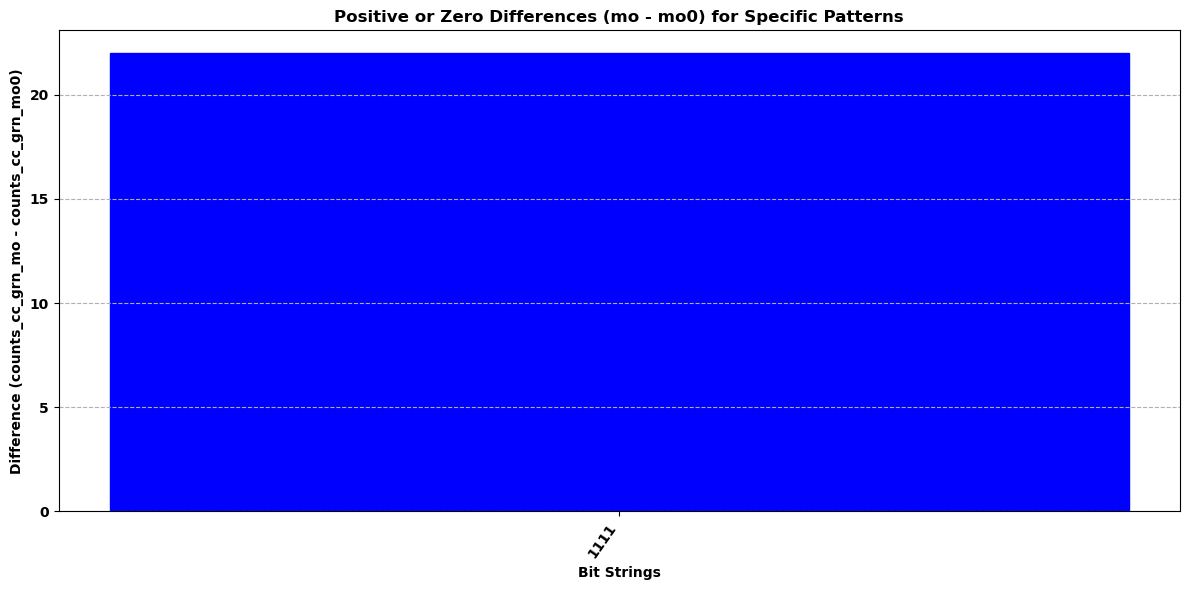

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assume counts_cc_grn_mo0 and counts_cc_grn_mo are defined dictionaries here.
# Assume bitstring_patterns is a defined list of patterns here.

differences_mo = {}

# Calculate the differences, handling cases where bitstrings are not common
all_bitstrings = set(counts_cc_grn_mo0.keys()) | set(counts_cc_grn_mo.keys())

for key in all_bitstrings:
    count_mo0 = counts_cc_grn_mo0.get(key, 0)
    count_mo = counts_cc_grn_mo.get(key, 0)
    differences_mo[key] = count_mo - count_mo0

# Define the pattern matching function (assuming it's the same as before)
def matches_pattern(bitstring, pattern):
    if len(bitstring) != len(pattern):
        return False
    for i in range(len(bitstring)):
        if pattern[i] != '.' and pattern[i] != bitstring[i]:
            return False
    return True

# Filter bitstrings based on the defined patterns first
pattern_filtered_bitstrings = []
pattern_filtered_differences = []

for bitstring, difference in differences_mo.items():
    for pattern in bitstring_patterns:
        if matches_pattern(bitstring, pattern):
            # Keep this bitstring and difference if it matches any pattern
            pattern_filtered_bitstrings.append(bitstring)
            pattern_filtered_differences.append(difference)
            break # Move to the next bitstring once a match is found

# --- Filter for positive or zero differences ONLY ---
# Create new lists containing only the elements where the difference is >= 0
filtered_bitstrings_mo = [] # Use these names for the final lists
filtered_differences_mo = []

# Iterate through the pattern-filtered data and keep only positive/zero differences
for bitstring, difference in zip(pattern_filtered_bitstrings, pattern_filtered_differences):
    if difference > 0: # Keep only positive or zero differences
        filtered_bitstrings_mo.append(bitstring)
        filtered_differences_mo.append(difference)

# --- End of filtering for positive differences ---


# Sort the filtered bitstrings for better visualization
# This sorting now applies only to the bitstrings with positive differences
sorted_indices = np.argsort(filtered_bitstrings_mo)
filtered_bitstrings_mo = [filtered_bitstrings_mo[i] for i in sorted_indices]
filtered_differences_mo = [filtered_differences_mo[i] for i in sorted_indices] # Apply same sorting to differences


# Create the bar plot with the positively filtered data
plt.figure(figsize=(12, 6))
bars = plt.bar(filtered_bitstrings_mo, filtered_differences_mo, edgecolor='black')

# Color the bars - since we only have >=0 differences, all will typically be colored the same
for bar, diff in zip(bars, filtered_differences_mo):
    # Note: with >=0 filtering, only diff > 0 or diff == 0 will be plotted
    if diff > 0:
        bar.set_color('blue')  # Color for strictly positive differences
    else: # This handles diff == 0 cases
         bar.set_color('blue') # You can choose a different color here if you want 0s distinct

plt.xlabel('Bit Strings')
# Update ylabel to reflect the specific difference calculated in this block
plt.ylabel('Difference (counts_cc_grn_mo - counts_cc_grn_mo0)')
# Update title to reflect the specific data and filtering applied
plt.title('Positive or Zero Differences (mo - mo0) for Specific Patterns')
plt.xticks(rotation=55, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--')
plt.show()

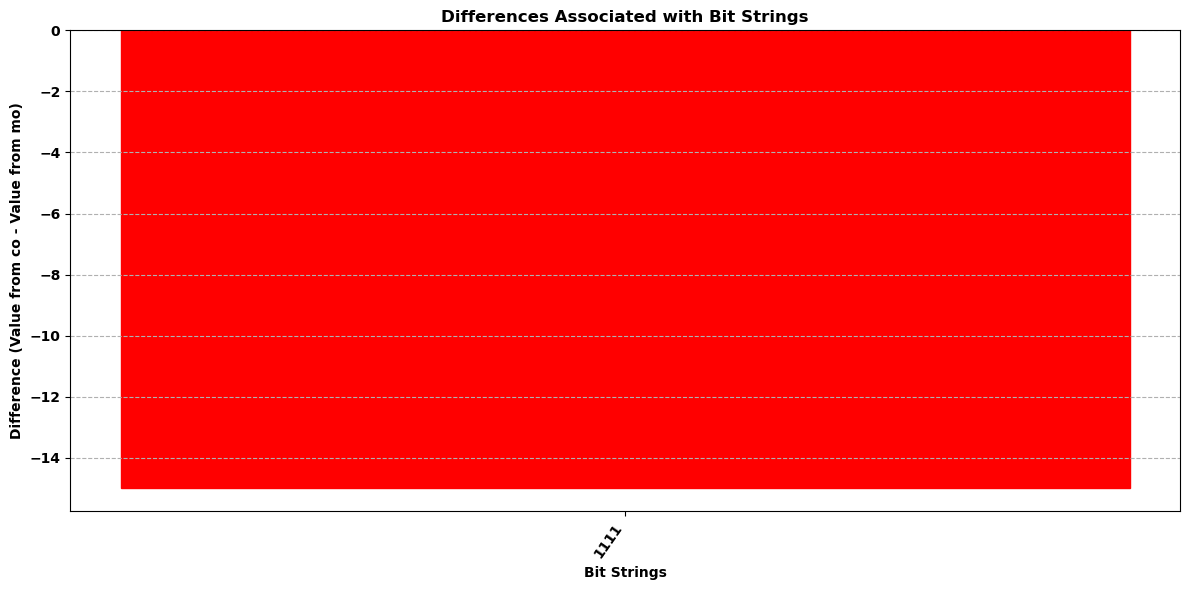

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


# We assume filtered_bitstrings_mo[i] corresponds to filtered_differences_mo[i], etc.
mo_data = dict(zip(filtered_bitstrings_mo, filtered_differences_mo))
co_data = dict(zip(filtered_bitstrings_co, filtered_differences_co))

all_bitstrings = set(mo_data.keys()) | set(co_data.keys())

# Initialize a dictionary to store the calculated differences
calculated_differences = {}

for bitstring in all_bitstrings:
    # Get the value for this bitstring from each dictionary
    # Use .get() with a default of 0 in case the bitstring is only in one list
    val_mo = mo_data.get(bitstring, 0)
    val_co = co_data.get(bitstring, 0)

    # Calculate the difference (co - mo)
    calculated_differences[bitstring] = val_co - val_mo

# 4. Prepare data for plotting (separate lists for bitstrings and differences)
plot_bitstrings = list(calculated_differences.keys())
plot_differences = list(calculated_differences.values())

# 5. Sort the data based on bitstring for better visualization (optional but recommended)
sorted_indices = np.argsort(plot_bitstrings)
plot_bitstrings = [plot_bitstrings[i] for i in sorted_indices]
plot_differences = [plot_differences[i] for i in sorted_indices]

# 6. Create the bar plot using the calculated differences
plt.figure(figsize=(12, 6))
bars = plt.bar(plot_bitstrings, plot_differences, edgecolor='black')

# 7. Color the bars based on the sign of the difference
for bar, diff in zip(bars, plot_differences):
    if diff > 0:
        bar.set_color('blue')  # Color for positive differences
    else:
        bar.set_color('red')   # Color for negative differences

plt.xlabel('Bit Strings')
plt.ylabel('Difference (Value from co - Value from mo)') # Updated label
plt.title('Differences Associated with Bit Strings')     # Updated title
plt.xticks(rotation=55, ha='right')
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.grid(axis='y', linestyle='--')
plt.show()

In [ ]:
print(gl_recv[::-1], gl_source[::-1])

['TGFB1', 'PDGFRB'] ['PDGFB', 'TGFBR2']


--- Concatenated DataFrame (bound_qc_co vs bound_qc_mo) ---
       Prob_0_co  Prob_1_co  Prob_0_mo  Prob_1_mo
Qubit                                            
0       0.143618   0.856382   0.417135   0.582865
1       0.574891   0.425109   0.703185   0.296815
2       0.948049   0.051951   0.811310   0.188690
3       0.251627   0.748373   0.276538   0.723462
------------------------------------------------------------
--- Concatenated DataFrame (bound_qc_co0 vs bound_qc_mo0) ---
       Prob_0_co0  Prob_1_co0  Prob_0_mo0  Prob_1_mo0
Qubit                                                
0        0.530021    0.469979    0.540076    0.459924
1        0.574891    0.425109    0.703185    0.296815
2        0.948049    0.051951    0.811310    0.188690
3        0.251627    0.748373    0.276538    0.723462
------------------------------------------------------------


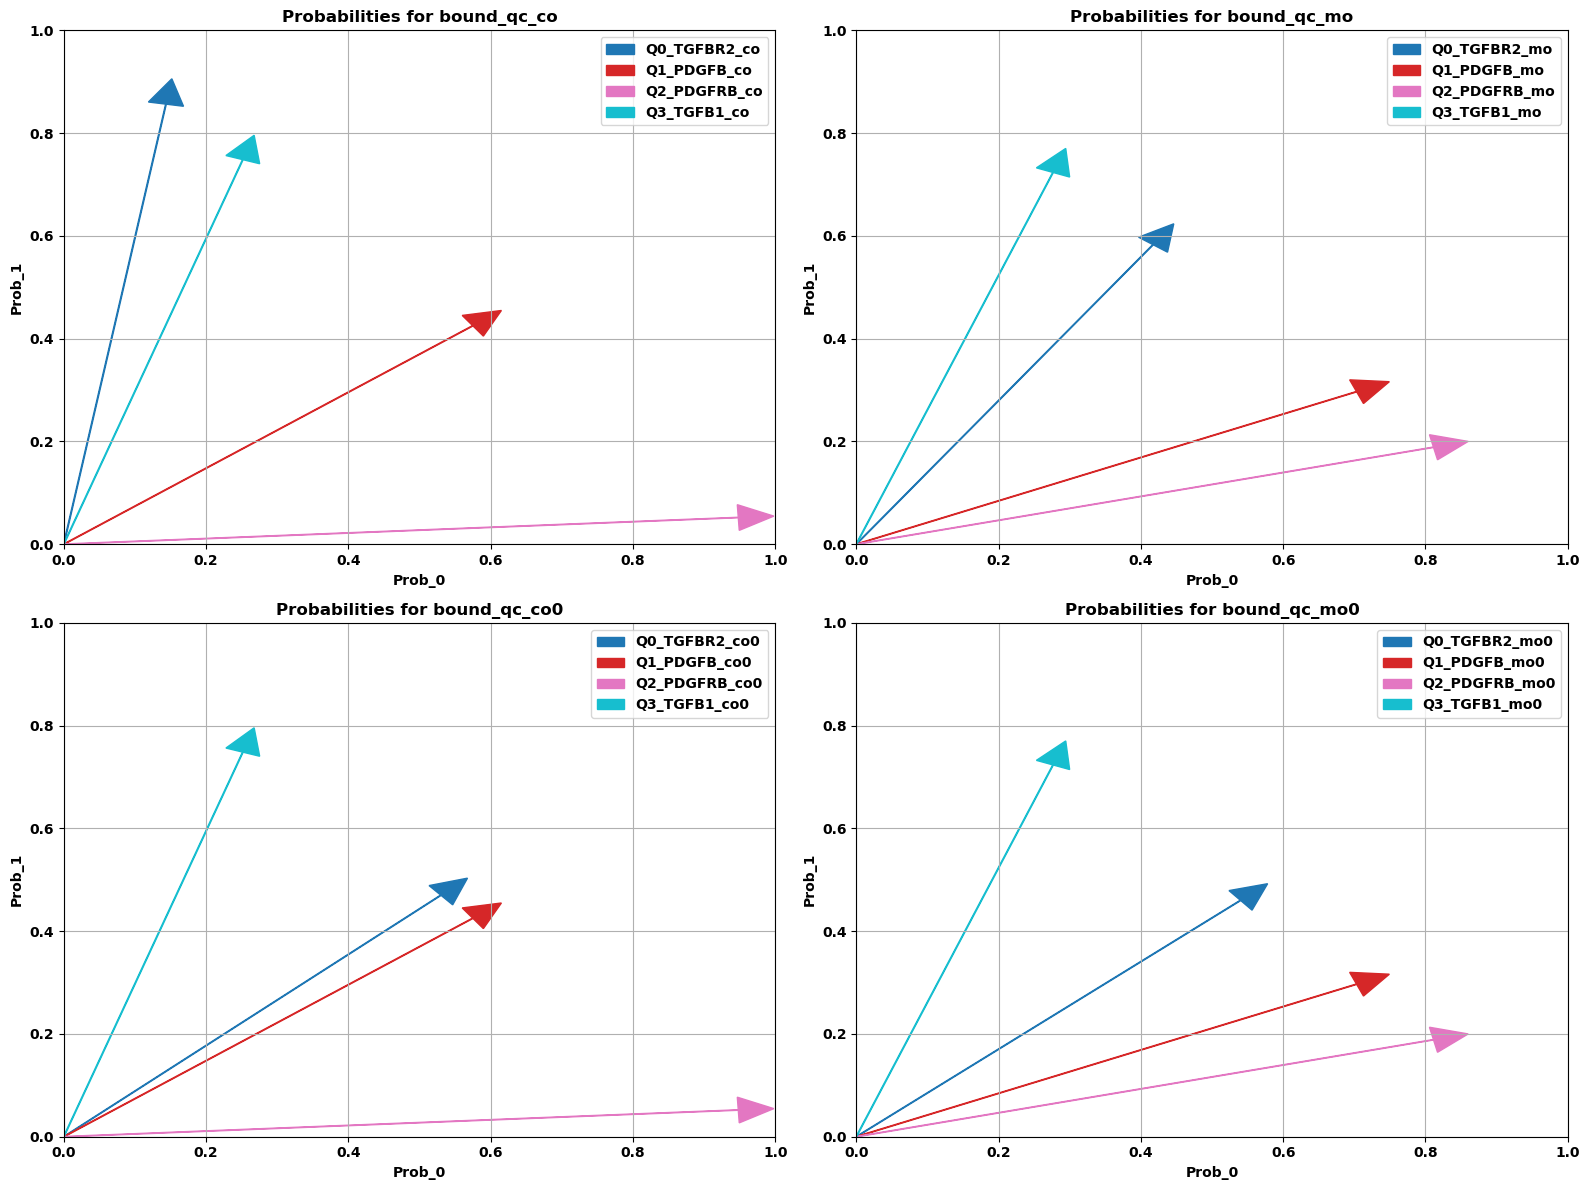

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # Import pandas for DataFrames
from qiskit.exceptions import QiskitError
from qiskit.quantum_info import DensityMatrix, Statevector, partial_trace

# Assuming the following variables are defined elsewhere:
# cc_grn_circuit_co, cc_grn_circuit_mo, cc_grn_circuit_co0, cc_grn_circuit_mo0
# all_params_lr_co, all_params_lr_mo, all_params_lr_co0, all_params_lr_mo0
# gl_source, gl_recv

# --- Data Calculation for bound_qc_co and bound_qc_mo ---
bound_qc_co_circ = cc_grn_circuit_co.copy()
bound_qc_co_circ.assign_parameters(all_params_lr_co, inplace=True)

bound_qc_mo_circ = cc_grn_circuit_mo.copy()
bound_qc_mo_circ.assign_parameters(all_params_lr_mo, inplace=True)

# Assume number of qubits is the same across all circuits
n_qubits = DensityMatrix(bound_qc_co_circ).num_qubits


co_data_bound = []
density_matrix_co_bound = DensityMatrix(bound_qc_co_circ)
for qubit_to_keep in range(n_qubits):
    trace_out_qubits = list(range(n_qubits))
    trace_out_qubits.pop(qubit_to_keep)
    reduced_density_matrix_data = partial_trace(density_matrix_co_bound, trace_out_qubits).data
    prob_0 = np.real(reduced_density_matrix_data[0, 0])
    prob_1 = np.real(reduced_density_matrix_data[1, 1])
    co_data_bound.append([qubit_to_keep, prob_0, prob_1])

mo_data_bound = []
density_matrix_mo_bound = DensityMatrix(bound_qc_mo_circ)
for qubit_to_keep in range(n_qubits):
    trace_out_qubits = list(range(n_qubits))
    trace_out_qubits.pop(qubit_to_keep)
    reduced_density_matrix_data = partial_trace(density_matrix_mo_bound, trace_out_qubits).data
    prob_0 = np.real(reduced_density_matrix_data[0, 0])
    prob_1 = np.real(reduced_density_matrix_data[1, 1])
    mo_data_bound.append([qubit_to_keep, prob_0, prob_1])

# Create DataFrames for bound data (add suffixes to column names)
co_df_bound = pd.DataFrame(co_data_bound, columns=['Qubit', 'Prob_0_co', 'Prob_1_co'])
mo_df_bound = pd.DataFrame(mo_data_bound, columns=['Qubit', 'Prob_0_mo', 'Prob_1_mo'])

# Concatenate DataFrames for bound data and print
concatenated_df_bound = pd.concat([co_df_bound.set_index('Qubit'), mo_df_bound.set_index('Qubit')], axis=1)
print("--- Concatenated DataFrame (bound_qc_co vs bound_qc_mo) ---")
print(concatenated_df_bound)
print("-" * 60) # Separator


# --- Data Calculation for bound_qc_co0 and bound_qc_mo0 ---
bound_qc_co0_circ = cc_grn_circuit_co0.copy()
bound_qc_co0_circ.assign_parameters(all_params_lr_co0, inplace=True)

bound_qc_mo0_circ = cc_grn_circuit_mo0.copy()
bound_qc_mo0_circ.assign_parameters(all_params_lr_mo0, inplace=True)

co_data_bound0 = []
density_matrix_co_bound0 = DensityMatrix(bound_qc_co0_circ)
for qubit_to_keep in range(n_qubits):
    trace_out_qubits = list(range(n_qubits))
    trace_out_qubits.pop(qubit_to_keep)
    reduced_density_matrix_data = partial_trace(density_matrix_co_bound0, trace_out_qubits).data
    prob_0 = np.real(reduced_density_matrix_data[0, 0])
    prob_1 = np.real(reduced_density_matrix_data[1, 1])
    co_data_bound0.append([qubit_to_keep, prob_0, prob_1])

mo_data_bound0 = []
density_matrix_mo_bound0 = DensityMatrix(bound_qc_mo0_circ)
for qubit_to_keep in range(n_qubits):
    trace_out_qubits = list(range(n_qubits))
    trace_out_qubits.pop(qubit_to_keep)
    reduced_density_matrix_data = partial_trace(density_matrix_mo_bound0, trace_out_qubits).data
    prob_0 = np.real(reduced_density_matrix_data[0, 0])
    prob_1 = np.real(reduced_density_matrix_data[1, 1])
    mo_data_bound0.append([qubit_to_keep, prob_0, prob_1])

# Create DataFrames for bound0 data (add suffixes to column names)
co_df_bound0 = pd.DataFrame(co_data_bound0, columns=['Qubit', 'Prob_0_co0', 'Prob_1_co0'])
mo_df_bound0 = pd.DataFrame(mo_data_bound0, columns=['Qubit', 'Prob_0_mo0', 'Prob_1_mo0'])

# Concatenate DataFrames for bound0 data and print
concatenated_df_bound0 = pd.concat([co_df_bound0.set_index('Qubit'), mo_df_bound0.set_index('Qubit')], axis=1)
print("--- Concatenated DataFrame (bound_qc_co0 vs bound_qc_mo0) ---")
print(concatenated_df_bound0)
print("-" * 60) # Separator


# --- Plotting in a single 2x2 panel ---

# Create a figure with 2 rows and 2 columns of subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12)) # Adjust figsize as needed

# Define colors for each qubit using tab20 or tab10 (consistent coloring across plots)
if n_qubits <= 10:
    colors = plt.cm.tab10(np.linspace(0, 1, n_qubits))
else:
    colors = plt.cm.tab20(np.linspace(0, 1, n_qubits))

# Concatenate genes (assuming gl_source and gl_recv are lists of gene names corresponding to qubits)
genes = gl_source + gl_recv

# --- Plotting on each subplot ---

# Plot for bound_qc_co (Top-Left Subplot)
ax1 = axes[0, 0]
for index, row in co_df_bound.iterrows(): # Use co_df_bound here
    ax1.arrow(0, 0, row['Prob_0_co'], row['Prob_1_co'], # Use correct column names
              head_width=0.05, head_length=0.05, fc=colors[index], ec=colors[index],
              label=f"Q{int(row['Qubit'])}_{genes[index]}_co")

ax1.set_xlabel('Prob_0')
ax1.set_ylabel('Prob_1')
ax1.set_title('Probabilities for bound_qc_co')
ax1.grid(True)
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.legend()


# Plot for bound_qc_mo (Top-Right Subplot)
ax2 = axes[0, 1]
for index, row in mo_df_bound.iterrows(): # Use mo_df_bound here
    ax2.arrow(0, 0, row['Prob_0_mo'], row['Prob_1_mo'], # Use correct column names
              head_width=0.05, head_length=0.05, fc=colors[index], ec=colors[index],
              label=f"Q{int(row['Qubit'])}_{genes[index]}_mo")

ax2.set_xlabel('Prob_0')
ax2.set_ylabel('Prob_1')
ax2.set_title('Probabilities for bound_qc_mo')
ax2.grid(True)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.legend()


# Plot for bound_qc_co0 (Bottom-Left Subplot)
ax3 = axes[1, 0]
for index, row in co_df_bound0.iterrows(): # Use co_df_bound0 here
    ax3.arrow(0, 0, row['Prob_0_co0'], row['Prob_1_co0'], # Use correct column names
              head_width=0.05, head_length=0.05, fc=colors[index], ec=colors[index],
              label=f"Q{int(row['Qubit'])}_{genes[index]}_co0")

ax3.set_xlabel('Prob_0')
ax3.set_ylabel('Prob_1')
ax3.set_title('Probabilities for bound_qc_co0')
ax3.grid(True)
ax3.set_xlim(0, 1)
ax3.set_ylim(0, 1)
ax3.legend()


# Plot for bound_qc_mo0 (Bottom-Right Subplot)
ax4 = axes[1, 1]
for index, row in mo_df_bound0.iterrows(): # Use mo_df_bound0 here
    ax4.arrow(0, 0, row['Prob_0_mo0'], row['Prob_1_mo0'], # Use correct column names
              head_width=0.05, head_length=0.05, fc=colors[index], ec=colors[index],
              label=f"Q{int(row['Qubit'])}_{genes[index]}_mo0")

ax4.set_xlabel('Prob_0')
ax4.set_ylabel('Prob_1')
ax4.set_title('Probabilities for bound_qc_mo0')
ax4.grid(True)
ax4.set_xlim(0, 1)
ax4.set_ylim(0, 1)
ax4.legend()


# Adjust layout and display the plot
plt.tight_layout()
plt.show()